## 4. Feature Engineering Research Design

The feature engineering framework is motivated by the market microstructure literature reviewed in `Research_Notes.md`.

Instead of grouping features only by raw data fields, auction features are organized by four economic mechanisms:

Investor Beliefs
→ Trader Commitment & Updating
→ Order Aggregation Capacity
→ Price Discovery Quality

The objective is to describe not only the final auction state, but also how trading intentions, order-flow structure, and price discovery evolve before the opening price is formed.

### 4.1 Feature Dictionary

| Feature Name | Definition | Data Source | Time Window | Economic Mechanism | Status |
|---|---|---|---|---|---|
| `submit_imbalance` | Buy-sell submitted volume imbalance | qorder | 09:15–09:25 | Directional Order Pressure | Keep |
| `net_order_imbalance` | Net buy-sell imbalance after cancellation adjustment | qorder | 09:15–09:25 | Net Directional Pressure | Keep |
| `last_minute_submit_imbalance` | Submitted volume imbalance during final minute | qorder | 09:24–09:25 | Late-Stage Direction | Keep |
| `buy_price_divergence` | Volume-weighted standard deviation of buy order prices normalized by previous close | qorder | 09:15–09:25 | Buy-Side Belief Divergence | Add |
| `sell_price_divergence` | Volume-weighted standard deviation of sell order prices normalized by previous close | qorder | 09:15–09:25 | Sell-Side Belief Divergence | Add |
| `buy_sell_divergence_gap` | Buy price divergence minus sell price divergence | qorder | 09:15–09:25 | Divergence Asymmetry | Add |
| `cancel_volume_ratio` | Cancelled volume divided by submitted volume | qorder | 09:15–09:20 | Cancellation Behavior | Keep |
| `cancel_count_ratio` | Number of cancellation records divided by submission records | qorder | 09:15–09:20 | Cancellation Activity | Keep |
| `cancel_rate_by_order` | Share of submitted orders eventually cancelled | qorder | 09:15–09:20 | Order-Level Commitment | Keep |
| `median_order_lifetime_seconds` | Median time between order submission and cancellation | qorder | 09:15–09:20 | Order Commitment | Keep |
| `last_minute_submit_volume_share` | Final-minute submitted volume divided by total auction submitted volume | qorder | 09:24–09:25 | Late Trading Commitment | Keep |
| `last_minute_submit_count_share` | Final-minute submitted order count divided by total auction order count | qorder | 09:24–09:25 | Late Participation | Keep |
| `pre920_imbalance` | Order imbalance before cancellation restriction | qorder | 09:15–09:20 | Tentative Order Pressure | Add |
| `post920_imbalance` | Order imbalance after cancellation restriction | qorder | 09:20–09:25 | Committed Order Pressure | Add |
| `imbalance_shift` | Post-9:20 imbalance minus Pre-9:20 imbalance | qorder | Stage Transition | Information Updating | Add |
| `post920_volume_share` | Post-9:20 submitted volume divided by total auction volume | qorder | 09:20–09:25 | Commitment Intensity | Add |
| `imbalance_reversal` | Indicator that imbalance direction changes across 09:20 | qorder | Stage Transition | Directional Reassessment | Add |
| `n_orders` | Total number of auction orders | qorder | 09:15–09:25 | Market Participation | Keep |
| `n_submit_orders` | Number of submitted orders | qorder | 09:15–09:25 | Active Participation | Keep |
| `avg_submit_size` | Average submitted order volume | qorder | 09:15–09:25 | Order Size Structure | Keep |
| `median_submit_size` | Median submitted order volume | qorder | 09:15–09:25 | Typical Order Size | Keep |
| `largest_order_share` | Largest submitted order volume divided by total submitted volume | qorder | 09:15–09:25 | Large-Order Dominance | Modify |
| `order_size_hhi` | Sum of squared order-volume shares | qorder | 09:15–09:25 | Order Concentration | Add |
| `n_price_levels` | Number of unique submitted order prices | qorder | 09:15–09:25 | Participation Breadth | Add |
| `total_depth` | Aggregated bid and ask depth across available book levels | qtick | 09:15–09:25 | Market Depth | Validate |
| `depth_imbalance` | Bid depth minus ask depth normalized by total depth | qtick | 09:15–09:25 | Book Pressure | Validate |
| `net_imbalance_to_depth` | Net order imbalance scaled by available market depth | qorder + qtick | 09:15–09:25 | Pressure-to-Liquidity | Validate |
| `auction_price_range` | Maximum auction price minus minimum auction price, normalized by previous close | qtick | 09:15–09:25 | Price Path Dispersion | Validate |
| `auction_price_volatility` | Standard deviation of auction price changes | qtick | 09:15–09:25 | Auction Price Instability | Validate |
| `last_minute_price_change` | Price change during the final auction minute | qtick | 09:24–09:25 | Late Information Update | Validate |
| `price_reversal_count` | Number of price-change direction reversals during auction | qtick | 09:15–09:25 | Price Discovery Instability | Validate |

### 4.2 Feature Family Summary

| Feature Family | Core Question | Key Features |
|---|---|---|
| Investor Beliefs | What direction does the market express and how much do investors disagree? | `submit_imbalance`, `net_order_imbalance`, `buy_price_divergence` |
| Commitment & Updating | How do traders change behavior when cancellation flexibility disappears? | `cancel_rate_by_order`, `pre920_imbalance`, `post920_imbalance`, `imbalance_shift` |
| Order Aggregation Capacity | Can available liquidity and broad participation absorb order pressure? | `largest_order_share`, `order_size_hhi`, `total_depth`, `net_imbalance_to_depth` |
| Price Discovery Quality | Does the auction price become more stable as the market approaches opening? | `auction_price_range`, `auction_price_volatility`, `last_minute_price_change`, `price_reversal_count` |

### 4.3 Research Hypotheses

#### H1: Commitment Hypothesis

Post-9:20 order flow should contain stronger information about opening and early post-open price behavior than Pre-9:20 order flow.

Cancellation Allowed
→ Tentative Trading Intentions

Cancellation Restricted
→ More Committed Trading Intentions

Therefore:

Post-9:20 Features
> Pre-9:20 Features

in explaining opening and early post-open price behavior.

#### H2: Absorption Capacity Hypothesis

The price impact of auction order imbalance should depend on available liquidity and order-flow concentration.

High Order Pressure + Deep Market
→ Pressure may be absorbed

High Order Pressure + Thin Market
→ Larger potential price impact

Therefore, `net_imbalance_to_depth` may contain more information than raw `net_order_imbalance`.

Similarly, high `largest_order_share` or `order_size_hhi` may indicate temporary price pressure dominated by a small number of large orders.

#### H3: Price Discovery Hypothesis

Auctions with more stable late-stage price paths should exhibit better opening price discovery.

Stable Auction Price Path
→ Better Information Aggregation
→ More Efficient Opening Price
→ Lower Post-Open Reversal

Therefore, high `auction_price_volatility`, large `last_minute_price_change`, or frequent `price_reversal_count` may be associated with greater post-open price correction.

### 4.4 Feature Engineering Strategy

The first version of the feature set will follow three principles:

1. **Mechanism First**

Features are included because they represent an economic mechanism rather than simply because the raw field is available.

2. **Avoid Redundant Feature Expansion**

Highly similar statistics such as mean and median order lifetime will initially be compared using correlation analysis. Highly correlated features may be removed before predictive modeling.

3. **Validate Market Meaning Before Construction**

Features based on `qtick` auction prices and order-book depth will only be constructed after confirming the interpretation and availability of `new_price`, bid depth, and ask depth during 09:15–09:25.

The feature engineering process therefore follows:

Existing Baseline Features
→ Literature-Motivated Feature Expansion
→ Data Field Validation
→ Feature Distribution and Correlation Analysis
→ Hypothesis Testing
→ Predictive Modeling

## CODE
### Preparation

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

EPS = 1e-9

In [3]:
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

session = connect_ddb()

In [4]:
DB_PATH = "dfs://quota"

START_DATE = "2026.03.11"
END_DATE = "2026.04.10"

AUCTION_START = "09:15:00"
AUCTION_END = "09:25:00"

print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Auction window:", AUCTION_START, "to", AUCTION_END)

table_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")
qorder = loadTable("{DB_PATH}", "qorder")
qknock = loadTable("{DB_PATH}", "qknock")
"""

session.run(table_script)

print("Defined DolphinDB tables:")
print("- qtick  : Market State / Snapshot Data")
print("- qorder : Market Intention / Order Data")
print("- qknock : Market Execution / Trade Data")

Database: dfs://quota
Sample period: 2026.03.11 to 2026.04.10
Auction window: 09:15:00 to 09:25:00
Defined DolphinDB tables:
- qtick  : Market State / Snapshot Data
- qorder : Market Intention / Order Data
- qknock : Market Execution / Trade Data


In [5]:
codes_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code
from qtick
where date >= {START_DATE}
  and date <= {END_DATE}
  and (
        code like "00%.SZ"
        or code like "30%.SZ"
        or code like "60%.SH"
        or code like "68%.SH"
      )
order by code
"""

all_codes = session.run(codes_script)

def classify_board(code):
    if code.startswith("30") and code.endswith(".SZ"):
        return "chinext"
    elif (
        code.startswith("00") and code.endswith(".SZ")
        or code.startswith("60") and code.endswith(".SH")
    ):
        return "main_board"
    elif code.startswith("68") and code.endswith(".SH"):
        return "star"
    else:
        return "other"

all_codes["board"] = all_codes["code"].apply(classify_board)

display(all_codes["board"].value_counts())

main_pool = all_codes[all_codes["board"] == "main_board"]
chinext_pool = all_codes[all_codes["board"] == "chinext"]

main_sample = main_pool.sample(
    n=min(30, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(20, len(chinext_pool)),
    random_state=42
)

stock_pool = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes = stock_pool["code"].tolist()

print("Selected stocks:", len(sample_codes))

board
main_board    3196
chinext       1396
star           607
Name: count, dtype: int64

Selected stocks: 50


In [6]:
code_filter = ",".join([f'"{code}"' for code in sample_codes])
print(code_filter)

"600613.SH","002727.SZ","603222.SH","002189.SZ","002546.SZ","603808.SH","002825.SZ","603477.SH","002438.SZ","002783.SZ","605136.SH","600025.SH","600396.SH","000690.SZ","601727.SH","000026.SZ","600548.SH","002381.SZ","603922.SH","600353.SH","600117.SH","000995.SZ","600416.SH","002772.SZ","600380.SH","002918.SZ","600096.SH","001314.SZ","600382.SH","002650.SZ","300852.SZ","301090.SZ","300930.SZ","300663.SZ","301609.SZ","300816.SZ","301288.SZ","300662.SZ","300323.SZ","300475.SZ","300084.SZ","300920.SZ","300865.SZ","301198.SZ","300214.SZ","300275.SZ","300633.SZ","300082.SZ","300665.SZ","301092.SZ"


In [7]:
qtick_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select *
from qtick
where date >= {START_DATE}
  and date <= {END_DATE}
  and code in [{code_filter}]
  and time >= {AUCTION_START}
  and time < {AUCTION_END}
order by code, date, time
"""

qtick = session.run(qtick_script)

In [8]:
qorder_script = f"""
qorder = loadTable("{DB_PATH}", "qorder")

select *
from qorder
where date >= {START_DATE}
  and date <= {END_DATE}
  and code in [{code_filter}]
  and time >= {AUCTION_START}
  and time < {AUCTION_END}
order by code, date, time
"""

qorder = session.run(qorder_script)

In [9]:
qknock_script = f"""
qknock = loadTable("{DB_PATH}", "qknock")

select *
from qknock
where date >= {START_DATE}
  and date <= {END_DATE}
  and code in [{code_filter}]
  and time >= {AUCTION_START}
  and time <= {AUCTION_END}
order by code, date, time
"""

qknock = session.run(qknock_script)

In [10]:
def prepare_datetime(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df["datetime"] = pd.to_datetime(
        df["date"].dt.strftime("%Y-%m-%d")
        + " "
        + df["time"].astype(str),
        errors="coerce"
    )

    df["clock"] = df["datetime"].dt.time

    return df


qtick = prepare_datetime(qtick)
qorder = prepare_datetime(qorder)
qknock = prepare_datetime(qknock)

print("qtick :", qtick.shape)
print("qorder:", qorder.shape)
print("qknock:", qknock.shape)

print("\nSample period:")
print(qtick["date"].min(), "→", qtick["date"].max())

print("\nStocks:", qtick["code"].nunique())

C:\Users\work\AppData\Local\Temp\ipykernel_29124\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_29124\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_29124\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(


qtick : (69974, 80)
qorder: (1149044, 10)
qknock: (101518, 10)

Sample period:
2026-03-11 00:00:00 → 2026-04-10 00:00:00

Stocks: 50


### Auction Window Filter

In [11]:
# ============================================================
# 1. Build Unified Auction Event Table
# ============================================================

def build_auction_events(qorder, qknock):
    # SH + SZ submissions from qorder
    submit_events = qorder[qorder["order_type"] == 0].copy()

    submit_events["exchange"] = np.where(
        submit_events["code"].str.endswith(".SH"),
        "SH",
        np.where(submit_events["code"].str.endswith(".SZ"), "SZ", "OTHER")
    )

    submit_events["event_type"] = "submit"
    submit_events["event_price"] = submit_events["order_price"]
    submit_events["event_volume"] = submit_events["order_volume"]
    submit_events["source_table"] = "qorder"

    submit_events = submit_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SH cancellations from qorder
    sh_cancel_events = qorder[
        (qorder["code"].str.endswith(".SH")) &
        (qorder["order_type"] == 3)
    ].copy()

    sh_cancel_events["exchange"] = "SH"
    sh_cancel_events["event_type"] = "cancel"
    sh_cancel_events["event_price"] = np.nan
    sh_cancel_events["event_volume"] = sh_cancel_events["order_volume"]
    sh_cancel_events["source_table"] = "qorder"

    sh_cancel_events = sh_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SZ cancellations from qknock
    sz_cancel_raw = qknock[
        (qknock["code"].str.endswith(".SZ")) &
        (qknock["match_price"] == 0)
    ].copy()

    sz_cancel_raw["exchange"] = "SZ"
    sz_cancel_raw["event_type"] = "cancel"
    sz_cancel_raw["event_price"] = np.nan
    sz_cancel_raw["event_volume"] = sz_cancel_raw["match_volume"]
    sz_cancel_raw["source_table"] = "qknock"

    sz_cancel_raw["order_no"] = np.where(
        sz_cancel_raw["bid_order_no"] != 0,
        sz_cancel_raw["bid_order_no"],
        sz_cancel_raw["ask_order_no"]
    )

    qorder_side = qorder[
        qorder["order_type"] == 0
    ][
        ["code", "date", "order_no", "bs_flag"]
    ].copy()

    sz_cancel_events = sz_cancel_raw.merge(
        qorder_side,
        on=["code", "date", "order_no"],
        how="left"
    )

    sz_cancel_events = sz_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    auction_events = pd.concat(
        [submit_events, sh_cancel_events, sz_cancel_events],
        ignore_index=True
    )

    auction_events["is_submit"] = auction_events["event_type"] == "submit"
    auction_events["is_cancel"] = auction_events["event_type"] == "cancel"

    # 已验证：bs_flag=1 是 BID/Buy，bs_flag=2 是 ASK/Sell
    auction_events["is_buy"] = auction_events["bs_flag"] == 1
    auction_events["is_sell"] = auction_events["bs_flag"] == 2

    auction_events = auction_events.sort_values(
        ["code", "date", "datetime", "event_type"]
    ).reset_index(drop=True)

    auction_events["time_display"] = auction_events["clock"].apply(
    lambda x: x.strftime("%H:%M:%S.%f")[:-3] if pd.notna(x) else np.nan
    )

    return auction_events


auction_events = build_auction_events(qorder, qknock)

print("auction_events shape:", auction_events.shape)
display(
    auction_events[
        [
            "code", "date", "time_display", "exchange", "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ].head()
)

auction_events shape: (1162472, 17)


,code,date,time_display,exchange,order_no,bs_flag,event_type,event_price,event_volume,source_table
0,000026.SZ,2026-03-11,09:15:00.030,SZ,2514,2,submit,170900.0,100,qorder
1,000026.SZ,2026-03-11,09:15:00.040,SZ,2904,2,submit,166000.0,100,qorder
2,000026.SZ,2026-03-11,09:15:00.040,SZ,4642,2,submit,159300.0,4700,qorder
3,000026.SZ,2026-03-11,09:15:00.040,SZ,6000,2,submit,170900.0,3100,qorder
4,000026.SZ,2026-03-11,09:15:00.050,SZ,9278,2,submit,163200.0,800,qorder


In [12]:
event_summary = pd.crosstab(
    auction_events["exchange"],
    auction_events["event_type"],
    margins=True
)

display(event_summary)

event_type,cancel,submit,All
exchange,,,
SH,45220,656583,701803
SZ,13428,447241,460669
All,58648,1103824,1162472


In [13]:
# ============================================================
# 3. Define Auction Windows for Unified Events and qtick
# ============================================================

auction_start = pd.to_datetime("09:15:00").time()
pre920_end = pd.to_datetime("09:20:00").time()
post920_start = pd.to_datetime("09:20:00").time()
auction_end = pd.to_datetime("09:25:00").time()
last_min_start = pd.to_datetime("09:24:00").time()

# Unified order/cancel events
events_auction = auction_events[
    (auction_events["clock"] >= auction_start) &
    (auction_events["clock"] < auction_end)
].copy()

events_pre920 = events_auction[
    (events_auction["clock"] >= auction_start) &
    (events_auction["clock"] < pre920_end)
].copy()

events_post920 = events_auction[
    (events_auction["clock"] >= post920_start) &
    (events_auction["clock"] < auction_end)
].copy()

events_last_min = events_auction[
    (events_auction["clock"] >= last_min_start) &
    (events_auction["clock"] < auction_end)
].copy()

# qtick snapshots for depth / price-discovery features
qtick_auction = qtick[
    (qtick["clock"] >= auction_start) &
    (qtick["clock"] < auction_end)
].copy()

qtick_last_min = qtick[
    (qtick["clock"] >= last_min_start) &
    (qtick["clock"] < auction_end)
].copy()

print("events_auction:", events_auction.shape)
print("events_pre920:", events_pre920.shape)
print("events_post920:", events_post920.shape)
print("events_last_min:", events_last_min.shape)
print("qtick_auction:", qtick_auction.shape)
print("qtick_last_min:", qtick_last_min.shape)


events_auction: (1162472, 17)
events_pre920: (743967, 17)
events_post920: (418505, 17)
events_last_min: (178596, 17)
qtick_auction: (69974, 80)
qtick_last_min: (9531, 80)


In [14]:
stage_cancel_check = pd.DataFrame({
    "window": ["pre920", "post920", "last_minute"],
    "n_cancel_records": [
        events_pre920["is_cancel"].sum(),
        events_post920["is_cancel"].sum(),
        events_last_min["is_cancel"].sum()
    ],
    "cancel_volume": [
        events_pre920.loc[events_pre920["is_cancel"], "event_volume"].sum(),
        events_post920.loc[events_post920["is_cancel"], "event_volume"].sum(),
        events_last_min.loc[events_last_min["is_cancel"], "event_volume"].sum()
    ]
})

display(stage_cancel_check)

,window,n_cancel_records,cancel_volume
0,pre920,58648,1222326648
1,post920,0,0
2,last_minute,0,0


### Helper Function

In [15]:
# ============================================================
# Helper Functions
# ============================================================

EPS = 1e-9

def safe_divide(a, b):
    return a / (b + EPS)

def signed_imbalance(buy, sell):
    return safe_divide(buy - sell, buy + sell)

def volume_weighted_std(price, volume):
    price = np.asarray(price, dtype=float)
    volume = np.asarray(volume, dtype=float)

    mask = (~np.isnan(price)) & (~np.isnan(volume)) & (volume > 0)
    price = price[mask]
    volume = volume[mask]

    if len(price) == 0 or volume.sum() == 0:
        return np.nan

    mu = np.sum(price * volume) / np.sum(volume)
    var = np.sum(volume * (price - mu) ** 2) / np.sum(volume)
    return np.sqrt(var)

def hhi(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    total = x.sum()
    if total <= 0:
        return np.nan

    shares = x / total
    return np.sum(shares ** 2)

def count_price_reversals(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan

    diff = x.diff().dropna()
    signs = np.sign(diff)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return (signs != signs.shift(1)).sum()


### Identify Buy / Sell / Submit / Cancel

In [16]:
order_type_summary = (
    qorder
    .groupby("order_type")
    .agg(
        n_records=("order_no", "count"),
        n_unique_orders=("order_no", "nunique"),
        avg_volume=("order_volume", "mean"),
        median_volume=("order_volume", "median"),
        avg_price=("order_price", "mean")
    )
    .reset_index()
)

display(order_type_summary)

,order_type,n_records,n_unique_orders,avg_volume,median_volume,avg_price
0,0,1103824,465494,4069.695196,700.0,242467.06821
1,3,45220,41458,24587.709929,1100.0,0.00000


In [17]:
submit_orders = qorder[
    qorder["order_type"] == 0
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()

cancel_orders = qorder[
    qorder["order_type"] == 3
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()


cancel_match = cancel_orders.merge(
    submit_orders,
    on=["code", "date", "order_no"],
    how="left",
    suffixes=("_cancel", "_submit")
)

cancel_match["matched_submit"] = cancel_match["time_submit"].notna()

print("Cancellation records:", len(cancel_match))
print(
    "Matched to previous submit:",
    cancel_match["matched_submit"].sum()
)

print(
    "Match rate:",
    cancel_match["matched_submit"].mean()
)

Cancellation records: 45220
Matched to previous submit: 45220
Match rate: 1.0


### Baseline Order Features

In [18]:
def build_order_features(df, prefix=""):
    g = df.groupby(["code", "date"])

    out = g.agg(
        **{
            f"{prefix}n_orders": ("order_no", "count"),
            f"{prefix}n_submit_orders": ("is_submit", "sum"),
            f"{prefix}n_cancel_orders": ("is_cancel", "sum"),
            f"{prefix}total_submit_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].sum()
            ),
            f"{prefix}total_cancel_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_cancel"]].sum()
            ),
            f"{prefix}avg_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].mean()
            ),
            f"{prefix}median_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].median()
            ),
            f"{prefix}max_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].max()
            ),
        }
    ).reset_index()

    return out


base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

print(base_features["order_count_check"].value_counts().head())

display(base_features.head())

order_count_check
0    1100
Name: count, dtype: int64


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000026.SZ,2026-03-11,441,434,7,640600,33800,1476.036866,600.0,36200,0
1,000026.SZ,2026-03-12,338,332,6,642400,17500,1934.939759,900.0,36200,0
2,000026.SZ,2026-03-13,316,305,11,468200,36100,1535.081967,700.0,16300,0
3,000026.SZ,2026-03-16,262,259,3,394100,7000,1521.621622,700.0,19200,0
4,000026.SZ,2026-03-17,326,312,14,530800,64300,1701.282051,800.0,20000,0


In [19]:
flag_check = pd.crosstab(
    qorder["bs_flag"],
    qorder["order_type"],
    margins=True
)

display(flag_check)

order_type,0,3,All
bs_flag,,,
1,463524,23042,486566
2,640300,22178,662478
All,1103824,45220,1149044


The baseline order features summarize the overall **auction participation, order flow activity, and order size structure** for each stock-day observation.

- `n_orders`: total number of auction events, including submissions and cancellations.
- `n_submit_orders`: number of submitted orders.
- `n_cancel_orders`: number of cancellation events.
- `total_submit_volume`: total submitted order volume.
- `total_cancel_volume`: total cancelled order volume.
- `avg_submit_size`: average submitted order size.
- `median_submit_size`: median submitted order size.
- `max_submit_size`: largest submitted order size.

The `order_count_check` confirms that:

> `n_orders = n_submit_orders + n_cancel_orders`

for all **1,100 stock-day observations**, validating the construction of the unified auction event table.

该样本还显示，不同交易日的 **order flow structure** 存在显著差异。例如，相同的总提交量可能由不同数量的订单和不同规模的订单组合产生。此外，`median_submit_size` and `max_submit_size` 之间的巨大差距表明存在**right-skewed order size distribution**，即少数大额订单可能占集合竞价成交量的不成比例的大部分。

因此，仅凭总集合竞价成交量可能无法全面反映集合竞价参与情况。 These baseline features provide the starting point for constructing more detailed **order concentration, cancellation behavior, and order imbalance features**.

### Direction / Imbalance Features

In [20]:
# ============================================================
# Imbalance Features
# ============================================================

def build_imbalance_features(df, prefix=""):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]]

        buy_vol = submit.loc[submit["is_buy"], "event_volume"].sum()
        sell_vol = submit.loc[submit["is_sell"], "event_volume"].sum()

        cancel = sub[sub["is_cancel"]]
        buy_cancel = cancel.loc[cancel["is_buy"], "event_volume"].sum()
        sell_cancel = cancel.loc[cancel["is_sell"], "event_volume"].sum()

        submit_imb = signed_imbalance(buy_vol, sell_vol)

        net_buy = buy_vol - buy_cancel
        net_sell = sell_vol - sell_cancel
        net_imb = signed_imbalance(net_buy, net_sell)

        rows.append({
            "code": code,
            "date": date,
            f"{prefix}buy_submit_volume": buy_vol,
            f"{prefix}sell_submit_volume": sell_vol,
            f"{prefix}buy_cancel_volume": buy_cancel,
            f"{prefix}sell_cancel_volume": sell_cancel,
            f"{prefix}submit_imbalance": submit_imb,
            f"{prefix}net_order_imbalance": net_imb,
        })

    return pd.DataFrame(rows)


imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())


,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000026.SZ,2026-03-11,170800,469800,26200,7600,-0.466750,-0.523401
1,000026.SZ,2026-03-12,146200,496200,7100,10400,-0.544832,-0.554809
2,000026.SZ,2026-03-13,123600,344600,7900,28200,-0.472021,-0.464476
3,000026.SZ,2026-03-16,96500,297600,7000,0,-0.510277,-0.537587
4,000026.SZ,2026-03-17,189200,341600,24200,40100,-0.287114,-0.292605


### Imbalance Features

Imbalance features 用于衡量集合竞价阶段的 **direction and strength of buy-sell order pressure**，即买卖双方订单压力的方向与强度。

- `buy_submit_volume`: total submitted buy volume
- `sell_submit_volume`: total submitted sell volume
- `buy_cancel_volume`: total cancelled buy volume
- `sell_cancel_volume`: total cancelled sell volume
- `submit_imbalance`: 基于原始申报量计算的 **submitted order imbalance**
- `net_order_imbalance`: 调整撤单后的 **cancellation-adjusted order imbalance**

Imbalance 定义为：

\[
Imbalance = \frac{BuyVolume - SellVolume}{BuyVolume + SellVolume}
\]

因此：

- positive imbalance 表示 stronger **buy-side pressure**
- negative imbalance 表示 stronger **sell-side pressure**
- imbalance 越接近 0，说明 auction order flow 越平衡

从 `000026.SZ` 的样本可以看到，多个交易日的 `submit_imbalance` 均为负值，说明初始申报阶段的 `sell_submit_volume` 明显高于 `buy_submit_volume`，市场表现出较强的 **sell-side order pressure**。

但 `submit_imbalance` 与 `net_order_imbalance` 并不完全相同，其差异主要来自 **asymmetric cancellation behavior**。

例如 2026-03-11：

- `submit_imbalance = -0.4668`
- `net_order_imbalance = -0.5234`

当日 `buy_cancel_volume` 明显高于 `sell_cancel_volume`。在撤单调整后，剩余买方订单进一步减少，因此最终 order flow 表现出更强的 **sell-side dominance**。

相反，2026-03-13 的 `sell_cancel_volume` 高于 `buy_cancel_volume`，因此撤单后初始卖方压力有所减弱：

> `submit_imbalance = -0.4720`  
> `net_order_imbalance = -0.4645`

这一结果说明，raw submitted order flow 与 cancellation-adjusted order flow 描述的是两个不同阶段的 trading intention：

> **Submitted Intention → Cancellation Adjustment → Remaining Order Pressure**

因此，`submit_imbalance` 用于衡量 initially expressed order pressure，而 `net_order_imbalance` 更接近撤单行为发生后仍然保留在 auction 中的 **committed directional pressure**。

### Cancellation Features

In [21]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

cancel_features["cancel_rate_by_order"] = cancel_features["cancel_count_ratio"]

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000026.SZ,2026-03-11,0.052763,0.016129,0.016129
1,000026.SZ,2026-03-12,0.027242,0.018072,0.018072
2,000026.SZ,2026-03-13,0.077104,0.036066,0.036066
3,000026.SZ,2026-03-16,0.017762,0.011583,0.011583
4,000026.SZ,2026-03-17,0.121138,0.044872,0.044872


### Cancellation Features

Cancellation features 用于衡量投资者在集合竞价阶段 **withdraw previously submitted orders** 的行为，从而描述 initial trading intention 的稳定程度以及 **order commitment**。

- `cancel_volume_ratio`: cancelled volume / submitted volume，用于衡量被撤回订单的 **economic size**
- `cancel_count_ratio`: cancellation events / submitted orders，用于衡量撤单行为的 **frequency**
- `cancel_rate_by_order`: share of submitted orders eventually cancelled，用于衡量 order-level cancellation activity

从 `000026.SZ` 的样本可以看到，不同交易日的 cancellation behavior 存在明显差异。

例如，`cancel_volume_ratio` 在展示的几个交易日中约从 **1.8% 到 12.1%** 波动，说明不同 auction session 中，被撤回的 initially submitted liquidity 比例可能存在较大差异。

一个值得关注的现象是 **volume-based cancellation** 与 **count-based cancellation** 之间的差异。

例如 2026-03-17：

- `cancel_volume_ratio = 12.1%`
- `cancel_count_ratio = 4.5%`

被撤回的订单数量占比并不高，但 cancelled volume 占 total submitted volume 的比例明显更高。这说明当日的 cancellation activity 可能集中在相对较大的订单上。

因此：

> **Cancellation Count → Frequency of Order Withdrawal**

> **Cancellation Volume → Economic Size of Withdrawn Interest**

两者反映不同维度的 trading behavior。大量 small-order cancellations 与少量 large-order cancellations 即使产生相似的 cancellation count，也可能代表完全不同的 order flow structure。

从 market microstructure 的角度看，cancellation behavior 可以作为 **order commitment** 的 proxy。较高的 cancellation activity 可能说明 initially expressed trading intention 稳定性较低；较低的 cancellation activity 则可能意味着订单在 auction process 中具有更强的 persistence。

因此，cancellation features 将与 `submit_imbalance` 和 `net_order_imbalance` 结合，用于描述：

> **Initial Order Pressure → Order Withdrawal → Remaining Committed Pressure**

这一过程有助于区分 raw order submission 中的 tentative trading intention 与撤单调整后更稳定的 **committed order flow**。

### Last-Minute Timing Features

In [22]:
# ============================================================
# Last-Minute Timing Features
# ============================================================

last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[[
    "code", "date",
    "total_submit_volume",
    "n_submit_orders"
]].merge(
    last_min_base[[
        "code", "date",
        "last_minute_total_submit_volume",
        "last_minute_n_submit_orders"
    ]],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[[
    "code", "date",
    "last_minute_submit_volume_share",
    "last_minute_submit_count_share"
]]

display(timing_features.head())


,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000026.SZ,2026-03-11,0.150328,0.122120
1,000026.SZ,2026-03-12,0.115349,0.099398
2,000026.SZ,2026-03-13,0.153567,0.104918
3,000026.SZ,2026-03-16,0.124080,0.146718
4,000026.SZ,2026-03-17,0.139412,0.092949


### Divergence Features

In [23]:
# ============================================================
# Divergence Features
# ============================================================

def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        # Use the median submitted price as scale if previous close is unavailable.
        # Because event_price and std are in the same price scale, the ratio is scale-free.
        ref_price = submit["event_price"].replace(0, np.nan).median()

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)


divergence_features = build_divergence_features(events_auction)
display(divergence_features.head())


,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000026.SZ,2026-03-11,0.040276,0.033856,0.006420
1,000026.SZ,2026-03-12,0.037675,0.038410,-0.000735
2,000026.SZ,2026-03-13,0.035849,0.035860,-0.000011
3,000026.SZ,2026-03-16,0.041171,0.045469,-0.004299
4,000026.SZ,2026-03-17,0.049641,0.049777,-0.000136


### Stage Transition Features: Pre-9:20 vs Post-9:20

In [24]:
# ============================================================
# Stage Transition Features: Pre-9:20 vs Post-9:20
# ============================================================

pre_imb = build_imbalance_features(events_pre920, prefix="pre920_")
post_imb = build_imbalance_features(events_post920, prefix="post920_")

stage_features = pre_imb.merge(
    post_imb,
    on=["code", "date"],
    how="outer"
)

stage_features["imbalance_shift"] = (
    stage_features["post920_submit_imbalance"] -
    stage_features["pre920_submit_imbalance"]
)

stage_features["imbalance_reversal"] = (
    np.sign(stage_features["post920_submit_imbalance"]) !=
    np.sign(stage_features["pre920_submit_imbalance"])
).astype(int)

post_volume = build_order_features(events_post920, prefix="post920_")
total_volume = base_features[["code", "date", "total_submit_volume"]]

stage_features = stage_features.merge(
    post_volume[["code", "date", "post920_total_submit_volume"]],
    on=["code", "date"],
    how="left"
).merge(
    total_volume,
    on=["code", "date"],
    how="left"
)

stage_features["post920_volume_share"] = safe_divide(
    stage_features["post920_total_submit_volume"],
    stage_features["total_submit_volume"]
)

stage_features = stage_features[
    [
        "code", "date",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share"
    ]
]

display(stage_features.head())


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000026.SZ,2026-03-11,-0.302784,-0.750320,-0.447536,0,0.366375
1,000026.SZ,2026-03-12,-0.443277,-0.683745,-0.240468,0,0.422323
2,000026.SZ,2026-03-13,-0.476216,-0.456212,0.020004,0,0.209739
3,000026.SZ,2026-03-16,-0.461838,-0.600874,-0.139036,0,0.348389
4,000026.SZ,2026-03-17,-0.243976,-0.359155,-0.115179,0,0.374529


### Stage Transition Features

Stage transition features 用于刻画 auction order flow 在 **09:20 cancellation restriction** 前后的变化。由于 09:15–09:20 阶段允许撤单，而 09:20–09:25 阶段不再接受撤单，这两个阶段代表不同程度的 **order commitment**。

- `pre920_submit_imbalance`: 09:15–09:20 的 submitted order imbalance
- `post920_submit_imbalance`: 09:20–09:25 的 submitted order imbalance
- `imbalance_shift`: post-09:20 imbalance 与 pre-09:20 imbalance 的变化
- `imbalance_reversal`: imbalance direction 是否在 09:20 前后发生 reversal
- `post920_volume_share`: 09:20 后 submitted volume 占整个 auction submitted volume 的比例

其中：ImbalanceShift=Post920Imbalance-Pre920Imbalance


因此，negative `imbalance_shift` 表示 order flow 在 09:20 后向 **sell-side pressure** 进一步移动；positive `imbalance_shift` 则表示 order flow 向 **buy-side pressure** 移动。

从 `000026.SZ` 的样本可以看到，多个交易日的 `imbalance_shift` 为负值，说明 sell-side pressure 在 cancellation restriction 生效后进一步增强。

例如 2026-03-11：

- `pre920_submit_imbalance = -0.3028`
- `post920_submit_imbalance = -0.7503`
- `imbalance_shift = -0.4475`

在允许撤单阶段，auction 已表现出一定的 sell-side imbalance；进入 non-cancellable stage 后，imbalance 明显进一步向卖方移动。这意味着后期提交的 committed order flow 具有更强的 **sell-side directional pressure**。

相比之下，2026-03-13：

- `pre920_submit_imbalance = -0.4762`
- `post920_submit_imbalance = -0.4562`
- `imbalance_shift = 0.0200`

前后两个阶段的 imbalance 基本稳定，说明 initial order pressure 在进入 non-cancellable stage 后并未发生明显变化，表现出较高的 **directional persistence**。

`imbalance_reversal` 用于识别更极端的 order flow updating behavior。当 pre-09:20 与 post-09:20 imbalance 符号相反时，该变量取 1，表示 auction direction 出现 **order flow reversal**。

`post920_volume_share` 则衡量 auction activity 中有多少比例发生在 cancellation restriction 之后。例如 2026-03-12 的 `post920_volume_share = 42.2%`，说明接近一半的 submitted volume 来自 non-cancellable stage，因此 post-09:20 imbalance 具有较高的 economic relevance。

整体而言，这组 features 描述了：

> **Early Auction Intention → Cancellation Restriction → Committed Order Flow**

相比 full-auction `submit_imbalance`，stage transition features 不仅衡量 order pressure 的方向，还进一步捕捉 trading intention 在制度切点前后的 **updating, persistence, and reversal behavior**。

### Order Concentration Features

In [25]:
# ============================================================
# Order Concentration Features
# ============================================================

def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0
            else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)


concentration_features = build_concentration_features(events_auction)
display(concentration_features.head())


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000026.SZ,2026-03-11,0.056510,0.012092,164
1,000026.SZ,2026-03-12,0.056351,0.015540,139
2,000026.SZ,2026-03-13,0.034814,0.011667,138
3,000026.SZ,2026-03-16,0.048719,0.013250,117
4,000026.SZ,2026-03-17,0.037679,0.012190,136


### Order Concentration Features

Order concentration features 用于衡量 auction order flow 是否集中在少数 **large orders**，以及 submitted orders 在 price dimension 上的分散程度。

- `largest_order_share`: largest submitted order volume / total submitted volume，衡量单笔最大订单对 auction volume 的占比
- `order_size_hhi`: 基于 individual order volume share 计算的 **Herfindahl-Hirschman Index (HHI)**，衡量整体 order size concentration
- `n_price_levels`: auction submissions 覆盖的 unique order price levels 数量，用于描述 **price dispersion / price-level diversity**

其中：
$$
LargestOrderShare = \frac{LargestOrderVolume}{TotalSubmittedVolume}
$$

`largest_order_share` 越高，说明 auction volume 越可能受到单笔 large order 的影响。

`order_size_hhi` 定义为：
$$
OrderSizeHHI = \sum_{i=1}^{N} \left(\frac{OrderVolume_i}{TotalSubmittedVolume}\right)^2
$$


较高的 HHI 表示 submitted volume 集中在少数 orders；较低的 HHI 则表示 order flow 更分散。

从 `000026.SZ` 的样本可以看到，`largest_order_share` 约为 **3.5%–5.7%**，说明单笔最大订单虽然具有一定 economic weight，但并未单独 dominate 整个 auction volume。

例如 2026-03-11：

- `largest_order_share = 5.65%`
- `order_size_hhi = 0.0121`
- `n_price_levels = 164`

相比之下，2026-03-12 的 `largest_order_share` 与前一交易日接近，但 `order_size_hhi` 从 0.0121 上升至 0.0155。

这说明即使 **largest single order exposure** 相似，整体 order size distribution 仍可能具有不同的 concentration structure。换言之，`largest_order_share` 主要捕捉 single-order dominance，而 `order_size_hhi` 衡量 broader order flow concentration。

这一结果也进一步说明，仅使用 `avg_submit_size` 或 `max_submit_size` 无法完整描述 auction participation structure。

> **Order Size → Large Order Exposure → Overall Order Concentration**

`n_price_levels` 则从 price dimension 描述 auction order flow。例如样本中的 unique price levels 从 117 到 164 不等，说明不同 trading days 的 submitted orders 在价格空间中的分布宽度存在差异。

因此，这组 features 用于区分两种可能具有相似 total submitted volume 的 auction：

> **Dispersed Participation:** volume 分散在大量 relatively small orders 中

> **Concentrated Participation:** volume 集中在少数 large orders 中

这种差异可能影响 auction price discovery，因为 concentrated order flow 更容易受到少数 large trading intentions 的影响，而 dispersed order flow 更可能反映 broader market participation。

### Depth Features from qtick

In [26]:
depth_cols_bid = [
    c for c in qtick_auction.columns
    if c.startswith("bv")
]

depth_cols_ask = [
    c for c in qtick_auction.columns
    if c.startswith("av")
]

print("Bid depth columns:", depth_cols_bid)
print("Ask depth columns:", depth_cols_ask)


def build_depth_features(df):

    if len(depth_cols_bid) == 0 or len(depth_cols_ask) == 0:
        return pd.DataFrame(
            columns=[
                "code",
                "date",
                "total_depth",
                "depth_imbalance",
                "last_minute_total_depth",
                "last_minute_depth_imbalance",
                "final_total_depth",
                "final_depth_imbalance"
            ]
        )

    temp = df.copy()

    # --------------------------------------------------------
    # Snapshot-level depth
    # --------------------------------------------------------

    temp["bid_depth"] = temp[
        depth_cols_bid
    ].sum(axis=1, skipna=True)

    temp["ask_depth"] = temp[
        depth_cols_ask
    ].sum(axis=1, skipna=True)

    temp["total_depth_snapshot"] = (
        temp["bid_depth"]
        + temp["ask_depth"]
    )

    temp["depth_imbalance_snapshot"] = safe_divide(
        temp["bid_depth"] - temp["ask_depth"],
        temp["bid_depth"] + temp["ask_depth"]
    )

    # --------------------------------------------------------
    # Full-auction average depth
    # --------------------------------------------------------

    avg_depth = (
        temp
        .groupby(["code", "date"])
        .agg(
            total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Last-minute average depth: 09:24–09:25
    # --------------------------------------------------------

    last_minute = temp[
        (temp["clock"] >= last_min_start) &
        (temp["clock"] < auction_end)
    ].copy()

    last_minute_depth = (
        last_minute
        .groupby(["code", "date"])
        .agg(
            last_minute_total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            last_minute_depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Final qtick snapshot before 09:25
    # --------------------------------------------------------

    final_snapshot = (
        temp
        .sort_values("datetime")
        .groupby(["code", "date"])
        .tail(1)
        .copy()
    )

    final_depth = final_snapshot[
        [
            "code",
            "date",
            "total_depth_snapshot",
            "depth_imbalance_snapshot"
        ]
    ].rename(
        columns={
            "total_depth_snapshot":
                "final_total_depth",

            "depth_imbalance_snapshot":
                "final_depth_imbalance"
        }
    )

    # --------------------------------------------------------
    # Merge depth feature families
    # --------------------------------------------------------

    out = (
        avg_depth
        .merge(
            last_minute_depth,
            on=["code", "date"],
            how="left"
        )
        .merge(
            final_depth,
            on=["code", "date"],
            how="left"
        )
    )

    return out


depth_features = build_depth_features(qtick_auction)

display(depth_features.head())

Bid depth columns: ['bv0', 'bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9']
Ask depth columns: ['av0', 'av1', 'av2', 'av3', 'av4', 'av5', 'av6', 'av7', 'av8', 'av9']


,code,date,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance
0,000026.SZ,2026-03-11,44466.666667,-0.220519,51171.428571,-0.144989,61900,-0.256866
1,000026.SZ,2026-03-12,26342.307692,-0.064359,49275.000000,-0.103268,48600,-0.049383
2,000026.SZ,2026-03-13,10107.142857,-0.081014,26975.000000,0.049799,29500,-0.003390
3,000026.SZ,2026-03-16,26159.090909,-0.424300,38660.000000,-0.324045,30900,0.042071
4,000026.SZ,2026-03-17,27687.500000,-0.136361,58640.000000,-0.085951,78200,-0.150895


### Order Book Depth Features

Order book depth features 基于 `qtick` 中的 **10-level bid and ask order book** 构造，用于描述集合竞价阶段 visible liquidity 的规模、方向以及临近开盘时的动态变化。

本研究从三个 time horizons 衡量 order book state：

- `total_depth`: full auction period 的 average visible depth
- `depth_imbalance`: full auction period 的 average bid-ask depth imbalance
- `last_minute_total_depth`: 09:24–09:25 的 average visible depth
- `last_minute_depth_imbalance`: 09:24–09:25 的 average depth imbalance
- `final_total_depth`: 09:25 前最后一个 qtick snapshot 的 visible depth
- `final_depth_imbalance`: final pre-open snapshot 的 depth imbalance

Depth imbalance 定义为：

$$
DepthImbalance = \frac{BidDepth - AskDepth}{BidDepth + AskDepth}
$$

因此：

- positive `depth_imbalance` 表示 stronger **bid-side depth**
- negative `depth_imbalance` 表示 stronger **ask-side depth**
- values closer to zero 表示 visible order book 更加 balanced

与前面的 `submit_imbalance` 不同，depth features 描述的是 **state of the visible order book**，而不是 order submission flow：

> **Order Imbalance → Flow of Trading Intentions**

> **Depth Imbalance → Visible Liquidity State**

从 `000026.SZ` 的样本可以看到，full-auction average、last-minute average 与 final snapshot 之间存在明显差异，说明 auction order book 在临近开盘过程中仍然持续发生 **liquidity updating**。

例如 2026-03-16：

- `depth_imbalance = -0.4243`
- `last_minute_depth_imbalance = -0.3240`
- `final_depth_imbalance = 0.0421`

Full auction period 中 visible depth 明显偏向 ask side，但随着 auction 接近 09:25，ask-side dominance 逐渐减弱，并在 final snapshot 中转变为轻微的 bid-side imbalance。

这一变化说明 full-auction average 可能无法完整反映 opening price formation 前的最终 order book condition。

类似地，2026-03-13：

- `depth_imbalance = -0.0810`
- `last_minute_depth_imbalance = 0.0498`
- `final_depth_imbalance = -0.0034`

Order book direction 在不同 observation windows 中发生变化，但 final snapshot 接近 balanced state。这体现了 auction price discovery 过程中 visible liquidity 的持续调整。

在 liquidity size 方面，多个交易日的 `last_minute_total_depth` 和 `final_total_depth` 明显高于 full-auction average `total_depth`。例如 2026-03-17：

- `total_depth = 27,688`
- `last_minute_total_depth = 58,640`
- `final_total_depth = 78,200`

这表明 visible liquidity 可能随着 opening price formation 临近而逐渐累积，即 trading interest 在 auction 后期表现出更高的 **liquidity concentration near the open**。

因此，本研究使用三个 observation horizons 描述 order book evolution：

> **Average Auction State → Last-Minute Liquidity State → Final Pre-Open State**

相比单一的 average depth measure，这种 multi-horizon construction 能够进一步捕捉 order book 的 **liquidity accumulation, directional updating, and final pre-open pressure**。

### Price Discovery Features

In [27]:
price_cols = [
    c for c in [
        "new_price", "open", "pre_close",
        "bp0", "ap0", "bp1", "ap1"
    ]
    if c in qtick_auction.columns
]

price_field_check = []

for col in price_cols:
    s = qtick_auction[col]
    price_field_check.append({
        "field": col,
        "n_records": len(s),
        "missing_rate": s.isna().mean(),
        "zero_rate": (s == 0).mean(),
        "n_unique_nonzero": s.replace(0, np.nan).nunique(dropna=True),
        "sample_nonzero_values": s.replace(0, np.nan).dropna().head(5).tolist()
    })

price_field_check = pd.DataFrame(price_field_check)
display(price_field_check)

,field,n_records,missing_rate,zero_rate,n_unique_nonzero,sample_nonzero_values
0,new_price,69974,0.0,1.000000,0,[]
1,open,69974,0.0,1.000000,0,[]
2,pre_close,69974,0.0,0.000000,879,"[15.54, 15.54, 15.54, 15.54, 15.54]"
3,bp0,69974,0.0,0.013062,3196,"[15.77, 15.65, 15.54, 15.77, 15.77]"
4,ap0,69974,0.0,0.013062,3196,"[15.77, 15.65, 15.54, 15.77, 15.77]"
5,bp1,69974,0.0,1.000000,0,[]
6,ap1,69974,0.0,1.000000,0,[]


In [28]:
# ============================================================
# Price Discovery Features
# Use mid-price proxy when new_price is unavailable in auction
# ============================================================

def build_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        # Prefer new_price if available; otherwise use best bid-ask midpoint
        price = None
        price_source = None

        if "new_price" in sub.columns:
            p = sub["new_price"].replace(0, np.nan)
            if p.notna().sum() >= 2:
                price = p
                price_source = "new_price"

        if price is None and {"bp0", "ap0"}.issubset(sub.columns):
            bp0 = sub["bp0"].replace(0, np.nan)
            ap0 = sub["ap0"].replace(0, np.nan)
            p = (bp0 + ap0) / 2

            if p.notna().sum() >= 2:
                price = p
                price_source = "mid_price_bp0_ap0"

        if price is None:
            rows.append({
                "code": code,
                "date": date,
                "price_source": np.nan,
                "auction_price_range": np.nan,
                "auction_price_volatility": np.nan,
                "last_minute_price_change": np.nan,
                "price_reversal_count": np.nan
            })
            continue

        price = price.dropna()

        ref_price = price.iloc[0]

        auction_price_range = safe_divide(
            price.max() - price.min(),
            ref_price
        )

        auction_price_volatility = price.pct_change().dropna().std()

        last = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        if price_source == "new_price":
            last_price = last["new_price"].replace(0, np.nan).dropna()
        else:
            last_bp0 = last["bp0"].replace(0, np.nan)
            last_ap0 = last["ap0"].replace(0, np.nan)
            last_price = ((last_bp0 + last_ap0) / 2).dropna()

        if len(last_price) >= 2:
            last_minute_price_change = safe_divide(
                last_price.iloc[-1] - last_price.iloc[0],
                last_price.iloc[0]
            )
        else:
            last_minute_price_change = np.nan

        price_diff = price.diff().dropna()
        signs = np.sign(price_diff)
        signs = signs[signs != 0]

        if len(signs) < 2:
            price_reversal_count = 0
        else:
            price_reversal_count = (
                signs != signs.shift(1)
            ).sum()

        rows.append({
            "code": code,
            "date": date,
            "auction_price_range": auction_price_range,
            "auction_price_volatility": auction_price_volatility,
            "last_minute_price_change": last_minute_price_change,
            "price_reversal_count": price_reversal_count
        })

    return pd.DataFrame(rows)


price_discovery_features = build_price_discovery_features(qtick_auction)
display(price_discovery_features.head())

,code,date,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,price_source
0,000026.SZ,2026-03-11,0.014585,0.006008,-0.001269,7.0,NaN
1,000026.SZ,2026-03-12,0.007124,0.001665,-0.003868,4.0,NaN
2,000026.SZ,2026-03-13,0.013636,0.006157,-0.010283,4.0,NaN
3,000026.SZ,2026-03-16,0.009278,0.001381,-0.003333,3.0,NaN
4,000026.SZ,2026-03-17,0.038488,0.007395,-0.006127,12.0,NaN


### Price Discovery Features

Price discovery features 用于描述集合竞价过程中 visible price state 的变化路径，以及 opening price formation 前价格信息的稳定程度。

Initial validation shows that `new_price` and `open` are not populated during the 09:15–09:25 auction window, with both fields equal to zero for all observations. Therefore, these fields cannot be used to reconstruct an indicative auction price path.

In contrast, `bp0` and `ap0` contain non-zero price information for approximately 98.7% of auction snapshots. 本研究因此使用 best bid-ask midpoint 构造 **visible price proxy**：

$$
MidPrice = \frac{bp0 + ap0}{2}
$$

需要注意的是，该 midpoint 并不是 official indicative clearing price。因此，本组 features 应被解释为 **visible order book price-path features**，而不是 official auction clearing price features。

- `auction_price_range`: full auction period 内 midpoint price range 相对于 initial midpoint 的比例
- `auction_price_volatility`: midpoint return path 的 volatility
- `last_minute_price_change`: 09:24–09:25 midpoint 的 relative price change
- `price_reversal_count`: midpoint price movement direction 的 reversal frequency

`auction_price_range` 用于衡量 auction price path 的整体 movement range。较高的 value 表示 visible price state 在 auction process 中经历更大的调整。

`auction_price_volatility` 衡量 midpoint returns 的 dispersion，用于描述 auction price discovery process 的短期 instability。

`last_minute_price_change` 重点观察 opening price formation 前最后一分钟的 price updating。由于 09:24–09:25 更接近 final auction matching point，该 feature 可以捕捉 **late-stage directional price movement**。

`price_reversal_count` 衡量 midpoint movement direction 发生改变的次数。较高的 reversal count 表示 price path 在 auction process 中反复调整，可能反映更强的 **price discovery uncertainty** 或 competing buy-sell pressure。

例如 2026-03-17：

- `auction_price_range = 3.85%`
- `auction_price_volatility = 0.0074`
- `last_minute_price_change = -0.61%`
- `price_reversal_count = 12`

相比其他展示交易日，当日 midpoint price path 具有更大的 movement range 与更频繁的 directional reversals，说明 visible price state 在 auction process 中经历了更明显的 **price updating and instability**。

相比之下，2026-03-12 的 `auction_price_range` 仅约为 0.71%，且 `price_reversal_count = 4`，表明 visible price path 相对更加稳定。

因此，这组 features 从 price dimension 描述 auction evolution：

> **Price Range → Price Volatility → Late-Stage Price Movement → Directional Reversal**

结合前面的 order flow 与 order book features，本研究分别从三个 microstructure channels 描述集合竞价过程：

> **Order Flow Channel → Trading Intention**

> **Order Book Channel → Visible Liquidity State**

> **Price Path Channel → Price Discovery Process**

### Pressure-to-Liquidity Features 

In [29]:
submit_events = events_auction[events_auction["is_submit"] == 1].copy()

buy_sell_volume = (
    submit_events
    .groupby(["code", "date"])
    .agg(
        total_buy_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_buy"] == 1].sum()
        ),
        total_sell_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_sell"] == 1].sum()
        )
    )
    .reset_index()
)

pressure_features = buy_sell_volume.copy()

pressure_features["raw_net_order_pressure"] = (
    pressure_features["total_buy_submit_volume"]
    - pressure_features["total_sell_submit_volume"]
)

pressure_features["raw_order_pressure_intensity"] = (
    pressure_features["raw_net_order_pressure"].abs()
)

pressure_features = pressure_features.merge(
    depth_features[["code", "date", "total_depth"]],
    on=["code", "date"],
    how="left"
)

valid_depth = pressure_features["total_depth"] > 0

pressure_features["net_pressure_to_depth"] = np.nan
pressure_features["pressure_intensity_to_depth"] = np.nan

pressure_features.loc[valid_depth, "net_pressure_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_net_order_pressure"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features.loc[valid_depth, "pressure_intensity_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_order_pressure_intensity"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features = pressure_features[
    [
        "code",
        "date",
        "net_pressure_to_depth",
        "pressure_intensity_to_depth"
    ]
]

display(pressure_features.head())
display(pressure_features.describe())

,code,date,net_pressure_to_depth,pressure_intensity_to_depth
0,000026.SZ,2026-03-11,-6.724138,6.724138
1,000026.SZ,2026-03-12,-13.286611,13.286611
2,000026.SZ,2026-03-13,-21.865724,21.865724
3,000026.SZ,2026-03-16,-7.687576,7.687576
4,000026.SZ,2026-03-17,-5.504289,5.504289


,date,net_pressure_to_depth,pressure_intensity_to_depth
count,1100,1094.000000,1094.000000
mean,2026-03-25 20:43:38.181818368,-15.649619,16.357020
min,2026-03-11 00:00:00,-539.675676,0.010198
25%,2026-03-18 00:00:00,-17.109800,3.591872
50%,2026-03-25 12:00:00,-8.187554,8.345550
75%,2026-04-02 00:00:00,-3.008644,17.331805
max,2026-04-10 00:00:00,55.362245,539.675676
std,NaN,33.790655,33.453641


### Execution Features

This section adds auction execution features from `qknock`.  
These features capture whether submitted auction interest actually leads to matched volume and value during the opening call auction.

In [30]:
print(qknock.columns.tolist())
display(qknock.head())

['code', 'date', 'time', 'match_no', 'bid_order_no', 'ask_order_no', 'match_price', 'match_volume', 'datetime', 'clock']


,code,date,time,match_no,bid_order_no,ask_order_no,match_price,match_volume,datetime,clock
0,000026.SZ,2026-03-11,1970-01-01 09:15:02.900,278203,0,169450,0,1000,2026-03-11 09:15:02.900000-01:00,09:15:02.900000
1,000026.SZ,2026-03-11,1970-01-01 09:15:24.770,347610,0,155134,0,6600,2026-03-11 09:15:24.770000-01:00,09:15:24.770000
2,000026.SZ,2026-03-11,1970-01-01 09:15:24.880,347636,155120,0,0,6100,2026-03-11 09:15:24.880000-01:00,09:15:24.880000
3,000026.SZ,2026-03-11,1970-01-01 09:16:47.080,374973,357497,0,0,6100,2026-03-11 09:16:47.080000-01:00,09:16:47.080000
4,000026.SZ,2026-03-11,1970-01-01 09:16:53.240,377262,371836,0,0,6200,2026-03-11 09:16:53.240000-01:00,09:16:53.240000


In [31]:
def build_execution_features(qknock_df):
    df = qknock_df.copy()

    # reconstruct datetime if needed
    if "datetime" not in df.columns:
        df["datetime"] = pd.to_datetime(
            df["date"].astype(str) + " " + df["time"].astype(str)
        )

    auction_trades = df[
        (df["clock"] >= auction_start) &
        (df["clock"] <= auction_end)
    ].copy()

    # If match_amount does not exist, calculate it
    if "match_amount" not in auction_trades.columns:
        auction_trades["match_amount"] = (
            auction_trades["match_price"] *
            auction_trades["match_volume"]
        )

    execution_features = (
        auction_trades
        .groupby(["code", "date"])
        .agg(
            auction_trade_count=("match_no", "nunique"),
            auction_trade_volume=("match_volume", "sum"),
            auction_trade_amount=("match_amount", "sum"),
            auction_avg_trade_price=("match_price", "mean")
        )
        .reset_index()
    )

    execution_features["auction_vwap"] = safe_divide(
        execution_features["auction_trade_amount"],
        execution_features["auction_trade_volume"]
    )

    return execution_features


execution_features = build_execution_features(qknock)

display(execution_features.head())
display(execution_features.describe())

,code,date,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_avg_trade_price,auction_vwap
0,000026.SZ,2026-03-11,45,57000,3642400000,132577.777778,63901.754386
1,000026.SZ,2026-03-12,26,40700,3584400000,118846.153846,88068.796069
2,000026.SZ,2026-03-13,29,50900,2274760000,95400.000000,44690.766208
3,000026.SZ,2026-03-16,36,22300,2287350000,137041.666667,102571.748879
4,000026.SZ,2026-03-17,48,119300,8046500000,103629.166667,67447.611065


,date,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_avg_trade_price,auction_vwap
count,746,746.000000,7.460000e+02,7.460000e+02,7.460000e+02,7.460000e+02
mean,2026-03-25 20:02:34.423592704,136.083110,3.435031e+05,3.487984e+10,2.007368e+05,1.551391e+05
min,2026-03-11 00:00:00,1.000000,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2026-03-18 00:00:00,23.250000,1.820000e+04,1.842705e+09,8.100799e+04,5.040486e+04
50%,2026-03-25 00:00:00,43.000000,5.340000e+04,4.413700e+09,1.199699e+05,8.846604e+04
75%,2026-04-02 00:00:00,100.000000,2.008500e+05,1.478022e+10,2.341907e+05,1.706170e+05
max,2026-04-10 00:00:00,6439.000000,2.879530e+07,3.088890e+12,1.491597e+06,1.448727e+06
std,NaN,387.140865,1.543521e+06,1.614797e+11,2.276756e+05,2.032805e+05


### Historical Features

This section adds lagged stock-level controls.  
Historical features help separate auction-specific signals from recent stock-level return, liquidity, and volatility conditions.

In [32]:
daily_features = (
    qtick
    .sort_values(["code", "date", "time"])
    .groupby(["code", "date"])
    .agg(
        daily_open=("open", "first"),
        daily_close=("new_price", "last"),
        daily_pre_close=("pre_close", "first"),
        daily_high=("new_price", "max"),
        daily_low=("new_price", "min"),
        daily_volume=("sum_volume", "last"),
        daily_amount=("sum_amount", "last"),
        upper_limit=("upper_limit", "first"),
        lower_limit=("lower_limit", "first")
    )
    .reset_index()
)

daily_features["daily_return"] = safe_divide(
    daily_features["daily_close"],
    daily_features["daily_pre_close"]
) - 1

daily_features["daily_range"] = safe_divide(
    daily_features["daily_high"] - daily_features["daily_low"],
    daily_features["daily_pre_close"]
)

daily_features = daily_features.sort_values(["code", "date"])

daily_features["prev_day_return"] = (
    daily_features.groupby("code")["daily_return"].shift(1)
)

daily_features["prev_day_amount"] = (
    daily_features.groupby("code")["daily_amount"].shift(1)
)

daily_features["rolling_5d_vol"] = (
    daily_features
    .groupby("code")["daily_return"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

daily_features["rolling_5d_amount"] = (
    daily_features
    .groupby("code")["daily_amount"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

daily_features["distance_to_upper_limit"] = safe_divide(
    daily_features["upper_limit"] - daily_features["daily_pre_close"],
    daily_features["daily_pre_close"]
)

daily_features["distance_to_lower_limit"] = safe_divide(
    daily_features["daily_pre_close"] - daily_features["lower_limit"],
    daily_features["daily_pre_close"]
)

historical_features = daily_features[
    [
        "code",
        "date",
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_vol",
        "rolling_5d_amount",
        "distance_to_upper_limit",
        "distance_to_lower_limit"
    ]
]

display(historical_features.head())
display(historical_features.describe())

,code,date,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,distance_to_upper_limit,distance_to_lower_limit
0,000026.SZ,2026-03-11,NaN,NaN,NaN,NaN,0.099743,0.099743
1,000026.SZ,2026-03-12,-1.0,0.0,NaN,NaN,0.099741,0.099741
2,000026.SZ,2026-03-13,-1.0,0.0,NaN,NaN,0.100000,0.100000
3,000026.SZ,2026-03-16,-1.0,0.0,NaN,NaN,0.100000,0.100000
4,000026.SZ,2026-03-17,-1.0,0.0,0.0,0.0,0.100275,0.100275


,date,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,distance_to_upper_limit,distance_to_lower_limit
count,1100,1050.0,1050.0,900.0,900.0,1100.000000,1100.000000
mean,2026-03-25 20:43:38.181818368,-1.0,0.0,0.0,0.0,0.139022,0.138968
min,2026-03-11 00:00:00,-1.0,0.0,0.0,0.0,0.049307,0.049254
25%,2026-03-18 00:00:00,-1.0,0.0,0.0,0.0,0.099974,0.099890
50%,2026-03-25 12:00:00,-1.0,0.0,0.0,0.0,0.100328,0.100241
75%,2026-04-02 00:00:00,-1.0,0.0,0.0,0.0,0.200000,0.200000
max,2026-04-10 00:00:00,-1.0,0.0,0.0,0.0,0.200569,0.200569
std,NaN,0.0,0.0,0.0,0.0,0.050291,0.050335


### Merge ALL Features

In [33]:
base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

display(base_features.head())
print(base_features["order_count_check"].value_counts().head())

,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000026.SZ,2026-03-11,441,434,7,640600,33800,1476.036866,600.0,36200,0
1,000026.SZ,2026-03-12,338,332,6,642400,17500,1934.939759,900.0,36200,0
2,000026.SZ,2026-03-13,316,305,11,468200,36100,1535.081967,700.0,16300,0
3,000026.SZ,2026-03-16,262,259,3,394100,7000,1521.621622,700.0,19200,0
4,000026.SZ,2026-03-17,326,312,14,530800,64300,1701.282051,800.0,20000,0


order_count_check
0    1100
Name: count, dtype: int64


In [34]:
imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())
display(last_min_imbalance.head())

,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000026.SZ,2026-03-11,170800,469800,26200,7600,-0.466750,-0.523401
1,000026.SZ,2026-03-12,146200,496200,7100,10400,-0.544832,-0.554809
2,000026.SZ,2026-03-13,123600,344600,7900,28200,-0.472021,-0.464476
3,000026.SZ,2026-03-16,96500,297600,7000,0,-0.510277,-0.537587
4,000026.SZ,2026-03-17,189200,341600,24200,40100,-0.287114,-0.292605


,code,date,last_minute_buy_submit_volume,last_minute_sell_submit_volume,last_minute_buy_cancel_volume,last_minute_sell_cancel_volume,last_minute_submit_imbalance,last_minute_net_order_imbalance
0,000026.SZ,2026-03-11,16700,79600,0,0,-0.653167,-0.653167
1,000026.SZ,2026-03-12,1800,72300,0,0,-0.951417,-0.951417
2,000026.SZ,2026-03-13,24000,47900,0,0,-0.332406,-0.332406
3,000026.SZ,2026-03-16,6400,42500,0,0,-0.738241,-0.738241
4,000026.SZ,2026-03-17,32900,41100,0,0,-0.110811,-0.110811


In [35]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

# order-level version
cancel_order_counts = (
    events_auction[events_auction["is_cancel"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_cancelled_unique_orders")
)

submit_order_counts = (
    events_auction[events_auction["is_submit"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_submitted_unique_orders")
)

cancel_rate_by_order = submit_order_counts.merge(
    cancel_order_counts,
    on=["code", "date"],
    how="left"
)

cancel_rate_by_order["n_cancelled_unique_orders"] = (
    cancel_rate_by_order["n_cancelled_unique_orders"].fillna(0)
)

cancel_rate_by_order["cancel_rate_by_order"] = safe_divide(
    cancel_rate_by_order["n_cancelled_unique_orders"],
    cancel_rate_by_order["n_submitted_unique_orders"]
)

cancel_features = cancel_features.merge(
    cancel_rate_by_order[
        ["code", "date", "cancel_rate_by_order"]
    ],
    on=["code", "date"],
    how="left"
)

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000026.SZ,2026-03-11,0.052763,0.016129,0.016129
1,000026.SZ,2026-03-12,0.027242,0.018072,0.018072
2,000026.SZ,2026-03-13,0.077104,0.036066,0.036066
3,000026.SZ,2026-03-16,0.017762,0.011583,0.011583
4,000026.SZ,2026-03-17,0.121138,0.044872,0.044872


In [36]:
last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[
    [
        "code", "date",
        "total_submit_volume",
        "n_submit_orders"
    ]
].merge(
    last_min_base[
        [
            "code", "date",
            "last_minute_total_submit_volume",
            "last_minute_n_submit_orders"
        ]
    ],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[
    [
        "code", "date",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share"
    ]
]

display(timing_features.head())

,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000026.SZ,2026-03-11,0.150328,0.122120
1,000026.SZ,2026-03-12,0.115349,0.099398
2,000026.SZ,2026-03-13,0.153567,0.104918
3,000026.SZ,2026-03-16,0.124080,0.146718
4,000026.SZ,2026-03-17,0.139412,0.092949


In [37]:
def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        ref_price = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .median()
        )

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)

In [38]:
def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0 else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)

In [39]:
divergence_features = build_divergence_features(events_auction)

concentration_features = build_concentration_features(events_auction)

display(divergence_features.head())
display(stage_features.head())
display(concentration_features.head())

,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000026.SZ,2026-03-11,0.040276,0.033856,0.006420
1,000026.SZ,2026-03-12,0.037675,0.038410,-0.000735
2,000026.SZ,2026-03-13,0.035849,0.035860,-0.000011
3,000026.SZ,2026-03-16,0.041171,0.045469,-0.004299
4,000026.SZ,2026-03-17,0.049641,0.049777,-0.000136


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000026.SZ,2026-03-11,-0.302784,-0.750320,-0.447536,0,0.366375
1,000026.SZ,2026-03-12,-0.443277,-0.683745,-0.240468,0,0.422323
2,000026.SZ,2026-03-13,-0.476216,-0.456212,0.020004,0,0.209739
3,000026.SZ,2026-03-16,-0.461838,-0.600874,-0.139036,0,0.348389
4,000026.SZ,2026-03-17,-0.243976,-0.359155,-0.115179,0,0.374529


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000026.SZ,2026-03-11,0.056510,0.012092,164
1,000026.SZ,2026-03-12,0.056351,0.015540,139
2,000026.SZ,2026-03-13,0.034814,0.011667,138
3,000026.SZ,2026-03-16,0.048719,0.013250,117
4,000026.SZ,2026-03-17,0.037679,0.012190,136


In [40]:
price_features_for_model = price_discovery_features[
    [
        "code",
        "date",
        "auction_price_range",
        "auction_price_volatility",
        "last_minute_price_change",
        "price_reversal_count"
    ]
].copy()

feature_tables = [
    base_features.drop(columns=["order_count_check"], errors="ignore"),
    imbalance_features,
    last_min_imbalance[
        [
            "code", "date",
            "last_minute_submit_imbalance",
            "last_minute_net_order_imbalance"
        ]
    ],
    cancel_features,
    timing_features,
    divergence_features,
    stage_features,
    concentration_features,
    depth_features,
    pressure_features,
    price_features_for_model
]

feature_df = feature_tables[0].copy()

for tbl in feature_tables[1:]:
    feature_df = feature_df.merge(
        tbl,
        on=["code", "date"],
        how="left"
    )

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

feature_df = (
    feature_df
    .merge(execution_features, on=["code", "date"], how="left")
    .merge(historical_features, on=["code", "date"], how="left")
)

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

print("Updated feature_df shape:", feature_df.shape)
display(feature_df.head())


Updated feature_df shape: (1100, 57)


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance,last_minute_submit_imbalance,last_minute_net_order_imbalance,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order,last_minute_submit_volume_share,last_minute_submit_count_share,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share,largest_order_share,order_size_hhi,n_price_levels,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_avg_trade_price,auction_vwap,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,distance_to_upper_limit,distance_to_lower_limit
0,000026.SZ,2026-03-11,441,434,7,640600,33800,1476.036866,600.0,36200,170800,469800,26200,7600,-0.466750,-0.523401,-0.653167,-0.653167,0.052763,0.016129,0.016129,0.150328,0.122120,0.040276,0.033856,0.006420,-0.302784,-0.750320,-0.447536,0,0.366375,0.056510,0.012092,164,44466.666667,-0.220519,51171.428571,-0.144989,61900,-0.256866,-6.724138,6.724138,0.014585,0.006008,-0.001269,7.0,45.0,57000.0,3.642400e+09,132577.777778,63901.754386,NaN,NaN,NaN,NaN,0.099743,0.099743
1,000026.SZ,2026-03-12,338,332,6,642400,17500,1934.939759,900.0,36200,146200,496200,7100,10400,-0.544832,-0.554809,-0.951417,-0.951417,0.027242,0.018072,0.018072,0.115349,0.099398,0.037675,0.038410,-0.000735,-0.443277,-0.683745,-0.240468,0,0.422323,0.056351,0.015540,139,26342.307692,-0.064359,49275.000000,-0.103268,48600,-0.049383,-13.286611,13.286611,0.007124,0.001665,-0.003868,4.0,26.0,40700.0,3.584400e+09,118846.153846,88068.796069,-1.0,0.0,NaN,NaN,0.099741,0.099741
2,000026.SZ,2026-03-13,316,305,11,468200,36100,1535.081967,700.0,16300,123600,344600,7900,28200,-0.472021,-0.464476,-0.332406,-0.332406,0.077104,0.036066,0.036066,0.153567,0.104918,0.035849,0.035860,-0.000011,-0.476216,-0.456212,0.020004,0,0.209739,0.034814,0.011667,138,10107.142857,-0.081014,26975.000000,0.049799,29500,-0.003390,-21.865724,21.865724,0.013636,0.006157,-0.010283,4.0,29.0,50900.0,2.274760e+09,95400.000000,44690.766208,-1.0,0.0,NaN,NaN,0.100000,0.100000
3,000026.SZ,2026-03-16,262,259,3,394100,7000,1521.621622,700.0,19200,96500,297600,7000,0,-0.510277,-0.537587,-0.738241,-0.738241,0.017762,0.011583,0.011583,0.124080,0.146718,0.041171,0.045469,-0.004299,-0.461838,-0.600874,-0.139036,0,0.348389,0.048719,0.013250,117,26159.090909,-0.424300,38660.000000,-0.324045,30900,0.042071,-7.687576,7.687576,0.009278,0.001381,-0.003333,3.0,36.0,22300.0,2.287350e+09,137041.666667,102571.748879,-1.0,0.0,NaN,NaN,0.100000,0.100000
4,000026.SZ,2026-03-17,326,312,14,530800,64300,1701.282051,800.0,20000,189200,341600,24200,40100,-0.287114,-0.292605,-0.110811,-0.110811,0.121138,0.044872,0.044872,0.139412,0.092949,0.049641,0.049777,-0.000136,-0.243976,-0.359155,-0.115179,0,0.374529,0.037679,0.012190,136,27687.500000,-0.136361,58640.000000,-0.085951,78200,-0.150895,-5.504289,5.504289,0.038488,0.007395,-0.006127,12.0,48.0,119300.0,8.046500e+09,103629.166667,67447.611065,-1.0,0.0,0.0,0.0,0.100275,0.100275


In [41]:
feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

missing_check = pd.DataFrame({
    "feature": feature_cols,
    "missing_rate": [
        feature_df[c].isna().mean()
        for c in feature_cols
    ],
    "n_unique": [
        feature_df[c].nunique(dropna=True)
        for c in feature_cols
    ]
}).sort_values("missing_rate", ascending=False)

display(missing_check)

,feature,missing_rate,n_unique
45,auction_trade_volume,0.321818,624
46,auction_trade_amount,0.321818,737
44,auction_trade_count,0.321818,247
48,auction_vwap,0.321818,739
47,auction_avg_trade_price,0.321818,736
52,rolling_5d_amount,0.181818,1
51,rolling_5d_vol,0.181818,1
50,prev_day_amount,0.045455,1
49,prev_day_return,0.045455,1
42,last_minute_price_change,0.042727,746


### Merged Feature Table Validation

After reconstructing exchange-aware auction events and rebuilding all feature families, the final `feature_df` contains one row per **stock-date** observation and one column per auction feature.

The merged table combines multiple microstructure channels:

- **Order Flow Channel**: order count, submitted/cancelled volume, buy-sell imbalance
- **Cancellation / Commitment Channel**: cancellation ratios and order-level cancellation rate
- **Stage Transition Channel**: pre-09:20 vs post-09:20 imbalance changes
- **Belief Divergence Channel**: buy-side and sell-side price dispersion
- **Order Concentration Channel**: large-order share, order-size HHI, price-level diversity
- **Order Book Channel**: average, last-minute, and final visible depth
- **Pressure-to-Liquidity Channel**: liquidity-adjusted imbalance
- **Price Discovery Channel**: midpoint price range, volatility, last-minute change, and reversal count

The first rows confirm that the feature construction is now internally consistent. For example, `n_orders` equals `n_submit_orders + n_cancel_orders`, and cancellation-related fields are no longer mechanically zero for SZ stocks after standardizing the exchange-specific event schema.

The missing value check shows that most features have a `missing_rate` of 0. This indicates that the core order-flow, cancellation, divergence, transition, concentration, and depth features are available for all 1,100 stock-date observations.

A small amount of missingness appears in several price-path and last-minute depth features:

- `last_minute_price_change`: 4.27%
- `last_minute_total_depth`: 2.00%
- `last_minute_depth_imbalance`: 2.00%
- `auction_price_volatility`: 1.82%
- `auction_price_range`: 1.09%
- `price_reversal_count`: 1.09%

These missing values are acceptable at this stage because they come from limited available qtick snapshots in specific late-auction windows rather than from failure of the full feature construction process.

Overall, the merged feature table is suitable for the next step: feature quality checking, redundancy analysis, and target construction.

In [42]:
redundant_features = [
    "cancel_count_ratio"
]

feature_df = feature_df.drop(
    columns=redundant_features,
    errors="ignore"
)

print("Removed redundant features:", redundant_features)
print("Updated feature_df shape:", feature_df.shape)

Removed redundant features: ['cancel_count_ratio']
Updated feature_df shape: (1100, 56)


### Feature Quality and Redundancy Check

The initial merged feature table contains **1,100 stock-date observations and 44 auction features** across multiple microstructure channels.

Feature missingness is generally low. Only six features contain missing values, and the highest missing rate is approximately 4.27% for `last_minute_price_change`.

These missing values mainly occur in **last-minute depth and price-path features**, where some stock-date observations do not contain sufficient qtick snapshots within the required observation window.

Importantly, missing values are not immediately replaced with zero. A missing observation indicates insufficient information to construct the feature, while zero represents an observed state with no measured change. Therefore, the two cases have different economic meanings.

Missing-value treatment will be performed after the time-based train-validation-test split to avoid **preprocessing leakage**.

A redundancy check also shows that `cancel_count_ratio` and `cancel_rate_by_order` are empirically identical across all 1,100 observations.

This occurs because each cancelled `order_no` in the current dataset corresponds to a single cancellation record. Therefore:

> **Cancellation Events = Unique Cancelled Orders**

As a result, the two features contain identical information.

`cancel_count_ratio` is removed, while `cancel_rate_by_order` is retained because its order-level interpretation is more closely aligned with the **Order Commitment Hypothesis**:

> `cancel_rate_by_order` measures the share of submitted orders that are eventually withdrawn.

After removing the redundant feature, the feature table contains **43 auction features** for subsequent feature diagnostics and predictive analysis.

### Feature Quality Check

In [43]:
feature_cols = [c for c in feature_df.columns if c not in ["code", "date"]]

quality = pd.DataFrame({
    "feature": feature_cols,
    "missing_rate": [feature_df[c].isna().mean() for c in feature_cols],
    "inf_count": [np.isinf(feature_df[c].replace([np.inf, -np.inf], np.nan)).sum() for c in feature_cols],
    "n_unique": [feature_df[c].nunique(dropna=True) for c in feature_cols],
    "mean": [feature_df[c].mean() if pd.api.types.is_numeric_dtype(feature_df[c]) else np.nan for c in feature_cols],
    "std": [feature_df[c].std() if pd.api.types.is_numeric_dtype(feature_df[c]) else np.nan for c in feature_cols],
})

quality.sort_values("missing_rate", ascending=False).head(30)

,feature,missing_rate,inf_count,n_unique,mean,std
44,auction_trade_volume,0.321818,0,624,3.435031e+05,1.543521e+06
45,auction_trade_amount,0.321818,0,737,3.487984e+10,1.614797e+11
43,auction_trade_count,0.321818,0,247,1.360831e+02,3.871409e+02
47,auction_vwap,0.321818,0,739,1.551391e+05,2.032805e+05
46,auction_avg_trade_price,0.321818,0,736,2.007368e+05,2.276756e+05
51,rolling_5d_amount,0.181818,0,1,0.000000e+00,0.000000e+00
50,rolling_5d_vol,0.181818,0,1,0.000000e+00,0.000000e+00
49,prev_day_amount,0.045455,0,1,0.000000e+00,0.000000e+00
48,prev_day_return,0.045455,0,1,-1.000000e+00,0.000000e+00
41,last_minute_price_change,0.042727,0,746,-1.477230e-04,1.005284e-02


### Correlation Check

In [44]:
# ============================================================
# Feature Diagnostics: Constant, Duplicate, High Correlation
# ============================================================

feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

numeric_features = feature_df[feature_cols].select_dtypes(
    include=np.number
)

# 1. Constant / near-constant features
unique_count = numeric_features.nunique(dropna=True)

constant_features = unique_count[
    unique_count <= 1
].index.tolist()

near_constant_features = []

for col in numeric_features.columns:
    value_share = (
        numeric_features[col]
        .value_counts(normalize=True, dropna=False)
    )

    if len(value_share) > 0 and value_share.iloc[0] >= 0.95:
        near_constant_features.append(
            {
                "feature": col,
                "dominant_value": value_share.index[0],
                "dominant_share": value_share.iloc[0]
            }
        )

near_constant_features = pd.DataFrame(
    near_constant_features
)


# 2. Exact duplicate features
duplicate_pairs = []

cols = numeric_features.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if numeric_features[cols[i]].equals(
            numeric_features[cols[j]]
        ):
            duplicate_pairs.append(
                {
                    "feature_1": cols[i],
                    "feature_2": cols[j]
                }
            )

duplicate_pairs = pd.DataFrame(
    duplicate_pairs
)


# 3. Highly correlated feature pairs
corr = numeric_features.corr()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        corr_value = corr.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                {
                    "feature_1": corr.columns[i],
                    "feature_2": corr.columns[j],
                    "correlation": corr_value
                }
            )

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values(
        "correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    if len(high_corr_pairs) > 0
    else pd.DataFrame()
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Constant features:")
print(constant_features)

print("\nNear-constant features:")
display(near_constant_features)

print("\nExact duplicate feature pairs:")
display(duplicate_pairs)

print("\nHighly correlated feature pairs |corr| >= 0.90:")
display(high_corr_pairs)

Constant features:
['prev_day_return', 'prev_day_amount', 'rolling_5d_vol', 'rolling_5d_amount']

Near-constant features:


,feature,dominant_value,dominant_share
0,prev_day_return,-1.0,0.954545
1,prev_day_amount,0.0,0.954545



Exact duplicate feature pairs:


,feature_1,feature_2
0,last_minute_submit_imbalance,last_minute_net_order_imbalance
1,rolling_5d_vol,rolling_5d_amount



Highly correlated feature pairs |corr| >= 0.90:


,feature_1,feature_2,correlation
19,last_minute_submit_imbalance,last_minute_net_order_imbalance,1.000000
26,distance_to_upper_limit,distance_to_lower_limit,0.999986
0,n_orders,n_submit_orders,0.998951
11,total_cancel_volume,buy_cancel_volume,0.998408
23,net_pressure_to_depth,pressure_intensity_to_depth,-0.989721
10,total_cancel_volume,buy_submit_volume,0.988353
15,buy_submit_volume,total_depth,0.984844
9,total_submit_volume,total_depth,0.983828
14,buy_submit_volume,buy_cancel_volume,0.981380
7,total_submit_volume,buy_submit_volume,0.981122


### Prediction-Ready Feature Additions

The previous cells construct the core stock-day auction feature table. The following cells add a small number of price-path features that are useful candidates for the 09:30–09:35 return prediction task. These features are kept as **candidate predictors**, not as final conclusions.


In [45]:
# ============================================================
# Enhanced Price Discovery Features
# Keep only stable price-path features for prediction
# ============================================================

def get_visible_mid_price(sub):
    bp0 = pd.to_numeric(sub["bp0"], errors="coerce").replace(0, np.nan)
    ap0 = pd.to_numeric(sub["ap0"], errors="coerce").replace(0, np.nan)
    return (bp0 + ap0) / 2


def build_enhanced_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        if not {"bp0", "ap0"}.issubset(sub.columns):
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        price = get_visible_mid_price(sub).dropna()

        if len(price) < 3:
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        first_price = price.iloc[0]
        final_price = price.iloc[-1]

        last_min = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        last_min_price = get_visible_mid_price(last_min).dropna()
        last_observed_price = last_min_price.iloc[-1] if len(last_min_price) >= 1 else final_price

        initial_distance = abs(first_price - final_price)
        final_distance = abs(last_observed_price - final_price)

        convergence_speed = safe_divide(
            initial_distance - final_distance,
            initial_distance
        )

        price_diff = price.diff().dropna()
        total_path_movement = price_diff.abs().sum()
        net_movement = abs(final_price - first_price)

        price_path_smoothness = safe_divide(
            net_movement,
            total_path_movement
        )

        rows.append({
            "code": code,
            "date": date,
            "convergence_speed": convergence_speed,
            "price_path_smoothness": price_path_smoothness,
        })

    return pd.DataFrame(rows)


enhanced_price_discovery = build_enhanced_price_discovery_features(qtick_auction)

display(enhanced_price_discovery.head())


,code,date,convergence_speed,price_path_smoothness
0,000026.SZ,2026-03-11,1.0,0.021277
1,000026.SZ,2026-03-12,1.0,0.030303
2,000026.SZ,2026-03-13,0.0,0.000000
3,000026.SZ,2026-03-16,1.0,0.875000
4,000026.SZ,2026-03-17,1.0,0.028902


In [46]:
# ============================================================
# Price Revision Magnitude Features
# Use visible best bid-ask midpoint because new_price is often unavailable in auction
# ============================================================

def build_revision_magnitude_features(df):
    results = []

    for (code, date), g in df.groupby(["code", "date"]):
        g = g.sort_values("datetime").copy()

        bp0 = pd.to_numeric(g["bp0"], errors="coerce").replace(0, np.nan)
        ap0 = pd.to_numeric(g["ap0"], errors="coerce").replace(0, np.nan)
        mid_price = ((bp0 + ap0) / 2).dropna()

        n_price_revisions = 0
        avg_revision_magnitude = np.nan
        median_revision_magnitude = np.nan
        max_revision_magnitude = np.nan

        if len(mid_price) >= 2:
            mid_return = mid_price.pct_change().dropna()
            revisions = mid_return[mid_return != 0].abs()
            n_price_revisions = len(revisions)

            if n_price_revisions > 0:
                avg_revision_magnitude = revisions.mean()
                median_revision_magnitude = revisions.median()
                max_revision_magnitude = revisions.max()

        results.append({
            "code": code,
            "date": date,
            "n_price_revisions": n_price_revisions,
            "avg_price_revision_magnitude": avg_revision_magnitude,
            "median_price_revision_magnitude": median_revision_magnitude,
            "max_price_revision_magnitude": max_revision_magnitude,
        })

    return pd.DataFrame(results)


revision_features = build_revision_magnitude_features(qtick_auction)

display(revision_features.head())
display(revision_features.describe())


,code,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
0,000026.SZ,2026-03-11,10,0.009011,0.011097,0.014801
1,000026.SZ,2026-03-12,10,0.002129,0.001931,0.004534
2,000026.SZ,2026-03-13,7,0.006828,0.005810,0.012187
3,000026.SZ,2026-03-16,5,0.002127,0.000667,0.005302
4,000026.SZ,2026-03-17,19,0.006267,0.004084,0.023368


,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
count,1100,1100.000000,1058.000000,1058.000000,1058.000000
mean,2026-03-25 20:43:38.181818368,9.009091,0.007683,0.004676,0.024252
min,2026-03-11 00:00:00,0.000000,0.000156,0.000101,0.000156
25%,2026-03-18 00:00:00,4.000000,0.002602,0.001367,0.006301
50%,2026-03-25 12:00:00,7.000000,0.004654,0.002614,0.012787
75%,2026-04-02 00:00:00,12.000000,0.008321,0.004950,0.024410
max,2026-04-10 00:00:00,58.000000,0.166634,0.166634,0.284753
std,NaN,7.565060,0.010668,0.007839,0.037512


In [47]:
# ============================================================
# Merge prediction-ready price-path additions
# ============================================================

feature_df = feature_df.drop(
    columns=[
        "distance_to_final_mid",
        "price_path_inefficiency",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],
    errors="ignore"
)

feature_df = feature_df.merge(
    enhanced_price_discovery,
    on=["code", "date"],
    how="left"
).merge(
    revision_features,
    on=["code", "date"],
    how="left"
)

feature_df["price_reversal_rate"] = np.where(
    feature_df["n_price_revisions"] > 0,
    feature_df["price_reversal_count"] / feature_df["n_price_revisions"],
    np.nan
)

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

print("Updated feature_df shape:", feature_df.shape)
display(feature_df.head())


Updated feature_df shape: (1100, 63)


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance,last_minute_submit_imbalance,last_minute_net_order_imbalance,cancel_volume_ratio,cancel_rate_by_order,last_minute_submit_volume_share,last_minute_submit_count_share,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share,largest_order_share,order_size_hhi,n_price_levels,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_avg_trade_price,auction_vwap,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,distance_to_upper_limit,distance_to_lower_limit,convergence_speed,price_path_smoothness,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude,price_reversal_rate
0,000026.SZ,2026-03-11,441,434,7,640600,33800,1476.036866,600.0,36200,170800,469800,26200,7600,-0.466750,-0.523401,-0.653167,-0.653167,0.052763,0.016129,0.150328,0.122120,0.040276,0.033856,0.006420,-0.302784,-0.750320,-0.447536,0,0.366375,0.056510,0.012092,164,44466.666667,-0.220519,51171.428571,-0.144989,61900,-0.256866,-6.724138,6.724138,0.014585,0.006008,-0.001269,7.0,45.0,57000.0,3.642400e+09,132577.777778,63901.754386,NaN,NaN,NaN,NaN,0.099743,0.099743,1.0,0.021277,10,0.009011,0.011097,0.014801,0.700000
1,000026.SZ,2026-03-12,338,332,6,642400,17500,1934.939759,900.0,36200,146200,496200,7100,10400,-0.544832,-0.554809,-0.951417,-0.951417,0.027242,0.018072,0.115349,0.099398,0.037675,0.038410,-0.000735,-0.443277,-0.683745,-0.240468,0,0.422323,0.056351,0.015540,139,26342.307692,-0.064359,49275.000000,-0.103268,48600,-0.049383,-13.286611,13.286611,0.007124,0.001665,-0.003868,4.0,26.0,40700.0,3.584400e+09,118846.153846,88068.796069,-1.0,0.0,NaN,NaN,0.099741,0.099741,1.0,0.030303,10,0.002129,0.001931,0.004534,0.400000
2,000026.SZ,2026-03-13,316,305,11,468200,36100,1535.081967,700.0,16300,123600,344600,7900,28200,-0.472021,-0.464476,-0.332406,-0.332406,0.077104,0.036066,0.153567,0.104918,0.035849,0.035860,-0.000011,-0.476216,-0.456212,0.020004,0,0.209739,0.034814,0.011667,138,10107.142857,-0.081014,26975.000000,0.049799,29500,-0.003390,-21.865724,21.865724,0.013636,0.006157,-0.010283,4.0,29.0,50900.0,2.274760e+09,95400.000000,44690.766208,-1.0,0.0,NaN,NaN,0.100000,0.100000,0.0,0.000000,7,0.006828,0.005810,0.012187,0.571429
3,000026.SZ,2026-03-16,262,259,3,394100,7000,1521.621622,700.0,19200,96500,297600,7000,0,-0.510277,-0.537587,-0.738241,-0.738241,0.017762,0.011583,0.124080,0.146718,0.041171,0.045469,-0.004299,-0.461838,-0.600874,-0.139036,0,0.348389,0.048719,0.013250,117,26159.090909,-0.424300,38660.000000,-0.324045,30900,0.042071,-7.687576,7.687576,0.009278,0.001381,-0.003333,3.0,36.0,22300.0,2.287350e+09,137041.666667,102571.748879,-1.0,0.0,NaN,NaN,0.100000,0.100000,1.0,0.875000,5,0.002127,0.000667,0.005302,0.600000
4,000026.SZ,2026-03-17,326,312,14,530800,64300,1701.282051,800.0,20000,189200,341600,24200,40100,-0.287114,-0.292605,-0.110811,-0.110811,0.121138,0.044872,0.139412,0.092949,0.049641,0.049777,-0.000136,-0.243976,-0.359155,-0.115179,0,0.374529,0.037679,0.012190,136,27687.500000,-0.136361,58640.000000,-0.085951,78200,-0.150895,-5.504289,5.504289,0.038488,0.007395,-0.006127,12.0,48.0,119300.0,8.046500e+09,103629.166667,67447.611065,-1.0,0.0,0.0,0.0,0.100275,0.100275,1.0,0.028902,19,0.006267,0.004084,0.023368,0.631579


### Feature Family Mapping for Prediction

This mapping is used for feature organization and screening. For the 5-minute return prediction task, cancellation features are kept as **secondary candidates** rather than analyzed further by mechanism. The final decision should come from single-factor IC / Rank IC / group-return tests.


In [48]:
# ============================================================
# Feature Family Mapping
# ============================================================

feature_family = {
    "Direction": [
        "submit_imbalance",
        "net_order_imbalance",
        "last_minute_submit_imbalance",
        "last_minute_net_order_imbalance",
        "depth_imbalance",
        "net_pressure_to_depth",
    ],

    "Divergence / Distribution": [
        "buy_price_divergence",
        "sell_price_divergence",
        "buy_sell_divergence_gap",
        "largest_order_share",
        "order_size_hhi",
        "n_price_levels",
    ],

    "Timing / Stage Transition": [
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share",
    ],

    "Liquidity / Aggregation": [
        "n_orders",
        "n_submit_orders",
        "avg_submit_size",
        "median_submit_size",
        "max_submit_size",
        "total_depth",
        "pressure_intensity_to_depth",
    ],

    "Price Path": [
        "auction_price_range",
        "auction_price_volatility",
        "last_minute_price_change",
        "price_reversal_count",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],

    "Cancellation / Secondary": [
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order",
        "total_cancel_volume",
    ],
}

family_summary = []

for family, cols in feature_family.items():
    existing = [c for c in cols if c in feature_df.columns]
    missing = [c for c in cols if c not in feature_df.columns]

    family_summary.append({
        "family": family,
        "n_existing_features": len(existing),
        "existing_features": existing,
        "missing_features": missing,
    })

family_summary = pd.DataFrame(family_summary)
display(family_summary)


,family,n_existing_features,existing_features,missing_features
0,Direction,6,"[submit_imbalance, net_order_imbalance, last_m...",[]
1,Divergence / Distribution,6,"[buy_price_divergence, sell_price_divergence, ...",[]
2,Timing / Stage Transition,7,"[last_minute_submit_volume_share, last_minute_...",[]
3,Liquidity / Aggregation,7,"[n_orders, n_submit_orders, avg_submit_size, m...",[]
4,Price Path,11,"[auction_price_range, auction_price_volatility...",[]
5,Cancellation / Secondary,3,"[cancel_volume_ratio, cancel_rate_by_order, to...",[cancel_count_ratio]


In [49]:
# ============================================================
# Feature Registry for Next Notebook
# ============================================================

registry_rows = []

for family, cols in feature_family.items():
    for feature in cols:
        if feature not in feature_df.columns:
            continue

        if family == "Cancellation / Secondary":
            priority = "Secondary"
        elif family in ["Direction", "Divergence / Distribution", "Timing / Stage Transition", "Liquidity / Aggregation", "Price Path"]:
            priority = "Core Candidate"
        else:
            priority = "Candidate"

        registry_rows.append({
            "feature": feature,
            "family": family,
            "priority": priority,
            "missing_rate": feature_df[feature].isna().mean(),
            "n_unique": feature_df[feature].nunique(dropna=True),
        })

feature_registry = pd.DataFrame(registry_rows).sort_values(
    ["priority", "family", "feature"]
)

display(feature_registry)

core_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Core Candidate",
    "feature"
].tolist()

secondary_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Secondary",
    "feature"
].tolist()

print("Core candidate features:", len(core_candidate_features))
print("Secondary candidate features:", len(secondary_candidate_features))


,feature,family,priority,missing_rate,n_unique
4,depth_imbalance,Direction,Core Candidate,0.000000,1094
3,last_minute_net_order_imbalance,Direction,Core Candidate,0.000000,1097
2,last_minute_submit_imbalance,Direction,Core Candidate,0.000000,1097
1,net_order_imbalance,Direction,Core Candidate,0.000000,1100
5,net_pressure_to_depth,Direction,Core Candidate,0.005455,1094
0,submit_imbalance,Direction,Core Candidate,0.000000,1100
6,buy_price_divergence,Divergence / Distribution,Core Candidate,0.000000,1100
8,buy_sell_divergence_gap,Divergence / Distribution,Core Candidate,0.000000,1100
9,largest_order_share,Divergence / Distribution,Core Candidate,0.000000,1100
11,n_price_levels,Divergence / Distribution,Core Candidate,0.000000,283


Core candidate features: 37
Secondary candidate features: 3


### Correlation Diagnostics for Feature Screening

The goal here is not to prove a mechanism, but to identify redundancy before single-factor testing. Highly correlated features should be reviewed so that the 5-minute return model does not simply combine duplicated signals.


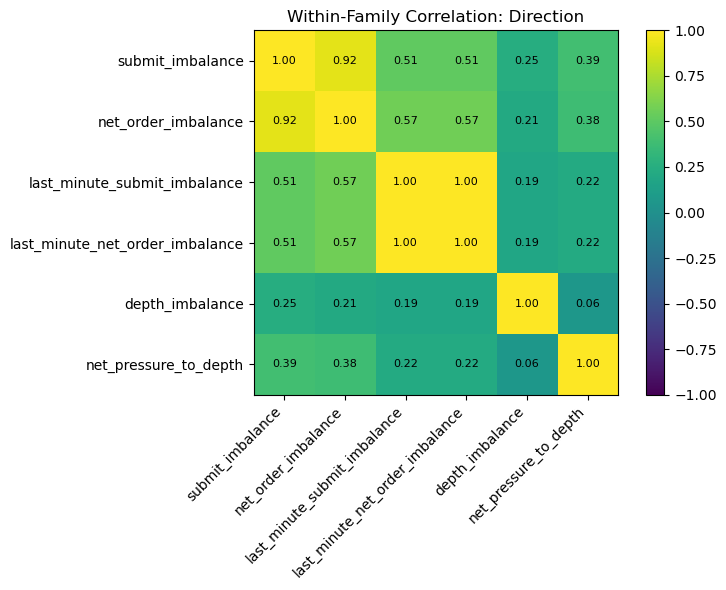

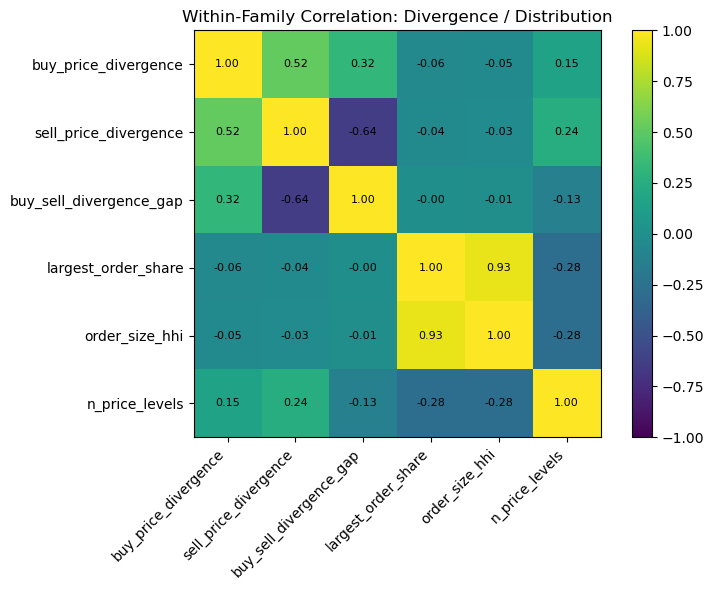

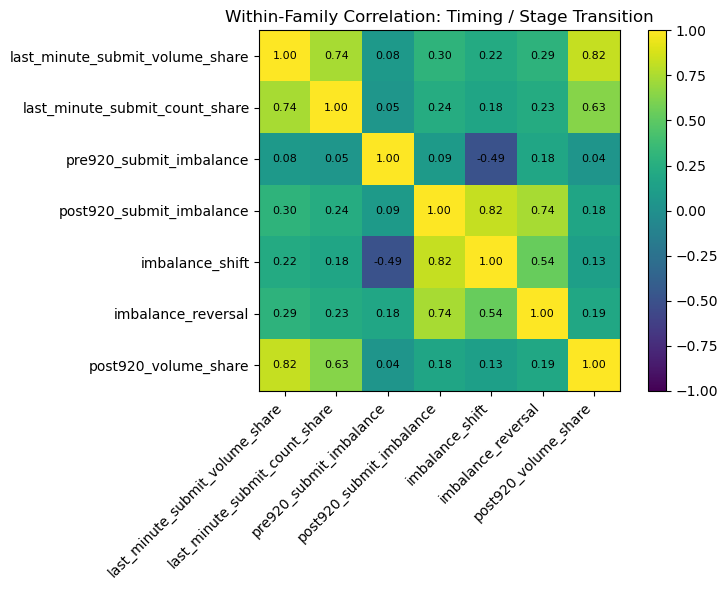

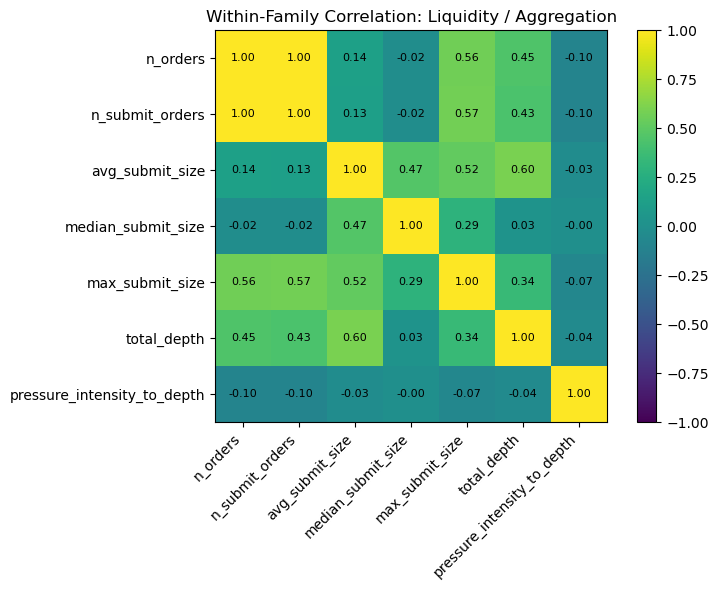

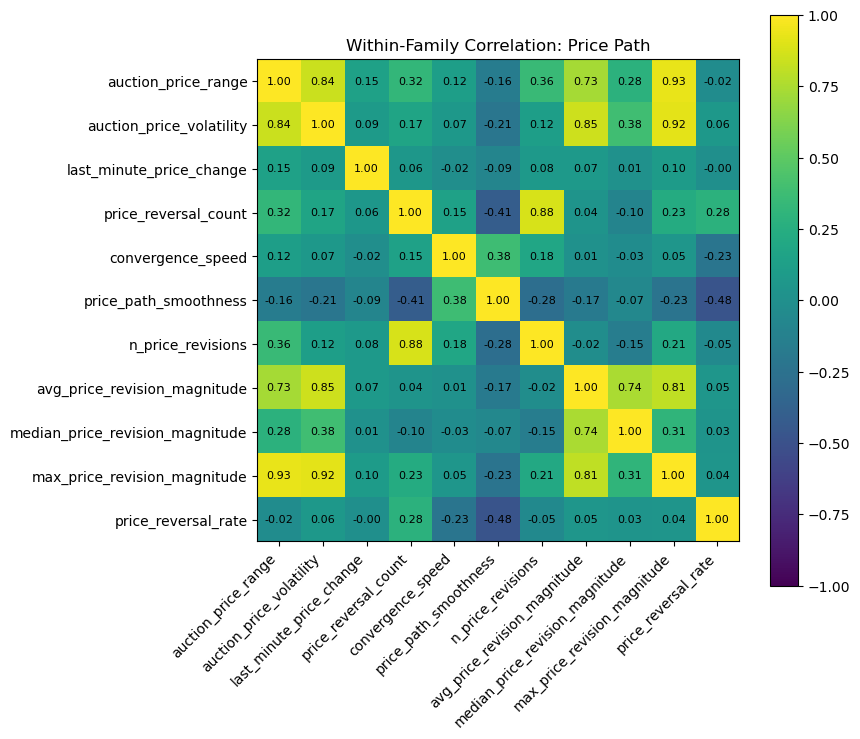

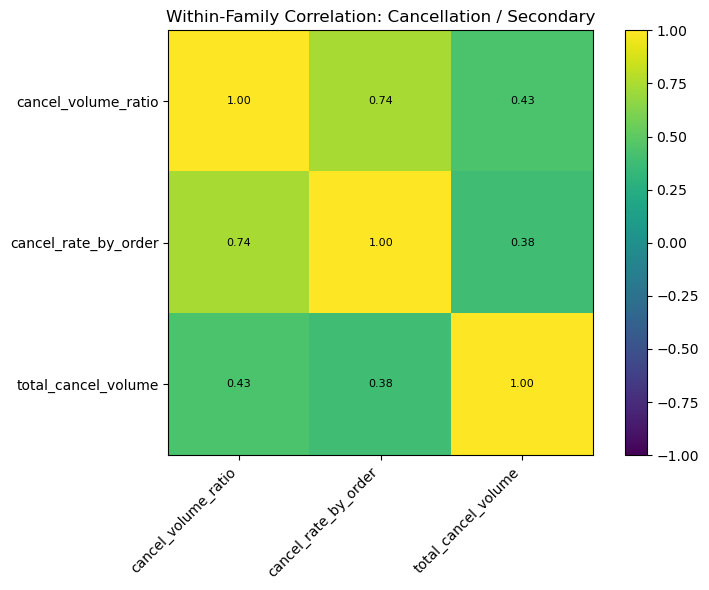

In [50]:
def plot_corr_heatmap(df, cols, title):
    existing = [c for c in cols if c in df.columns]

    if len(existing) < 2:
        print(f"Not enough features for {title}")
        return

    corr = df[existing].corr()

    fig, ax = plt.subplots(figsize=(max(8, len(existing) * 0.8), max(6, len(existing) * 0.7)))

    im = ax.imshow(corr, vmin=-1, vmax=1)

    ax.set_xticks(range(len(existing)))
    ax.set_yticks(range(len(existing)))
    ax.set_xticklabels(existing, rotation=45, ha="right")
    ax.set_yticklabels(existing)

    ax.set_title(title)

    for i in range(len(existing)):
        for j in range(len(existing)):
            value = corr.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


for family, cols in feature_family.items():
    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )

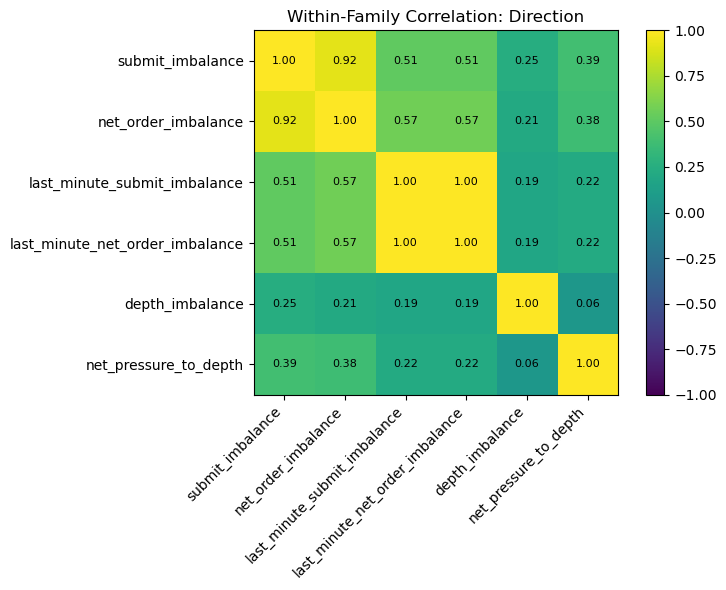

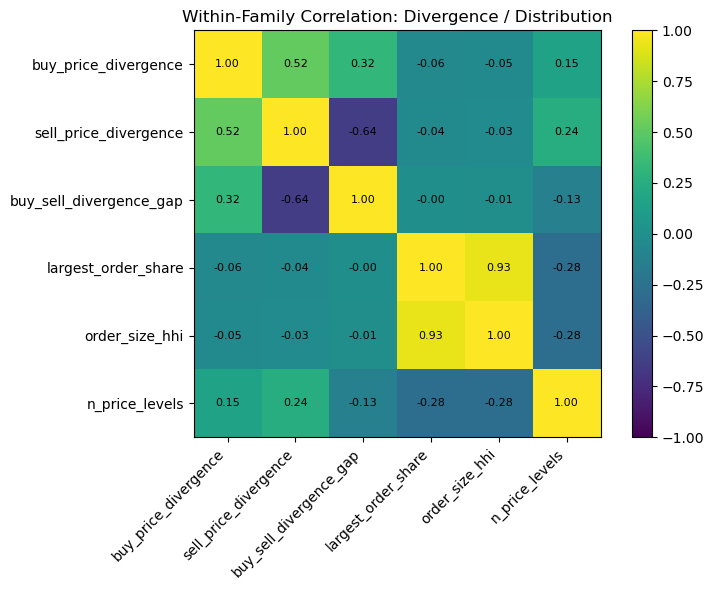

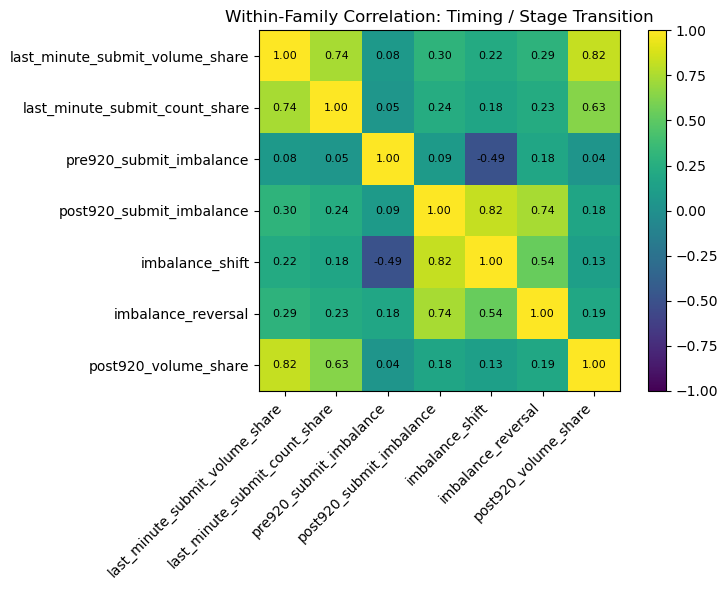

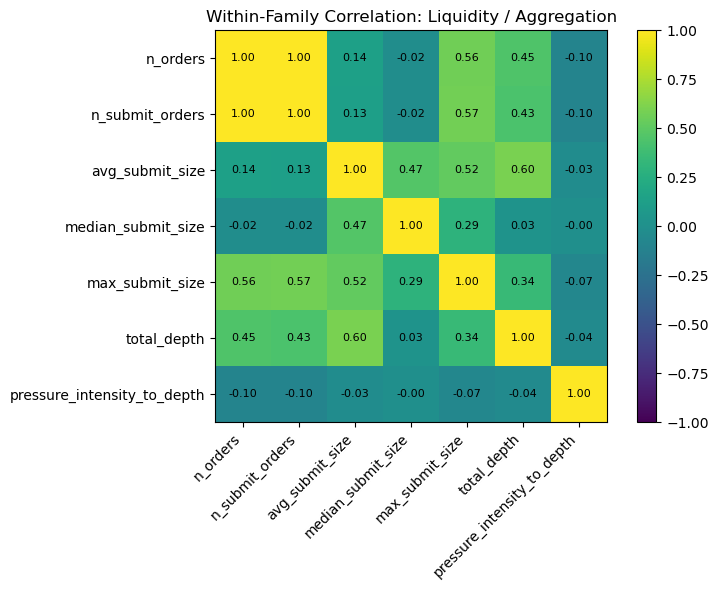

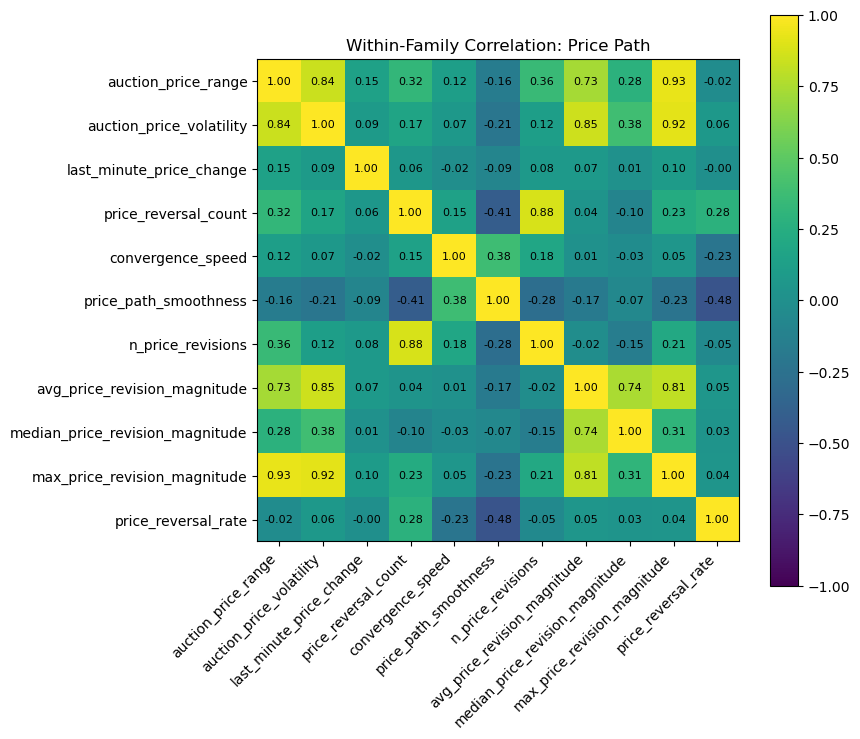

In [51]:
# Within-family correlation heatmaps
for family, cols in feature_family.items():
    if family == "Cancellation / Secondary":
        continue

    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )


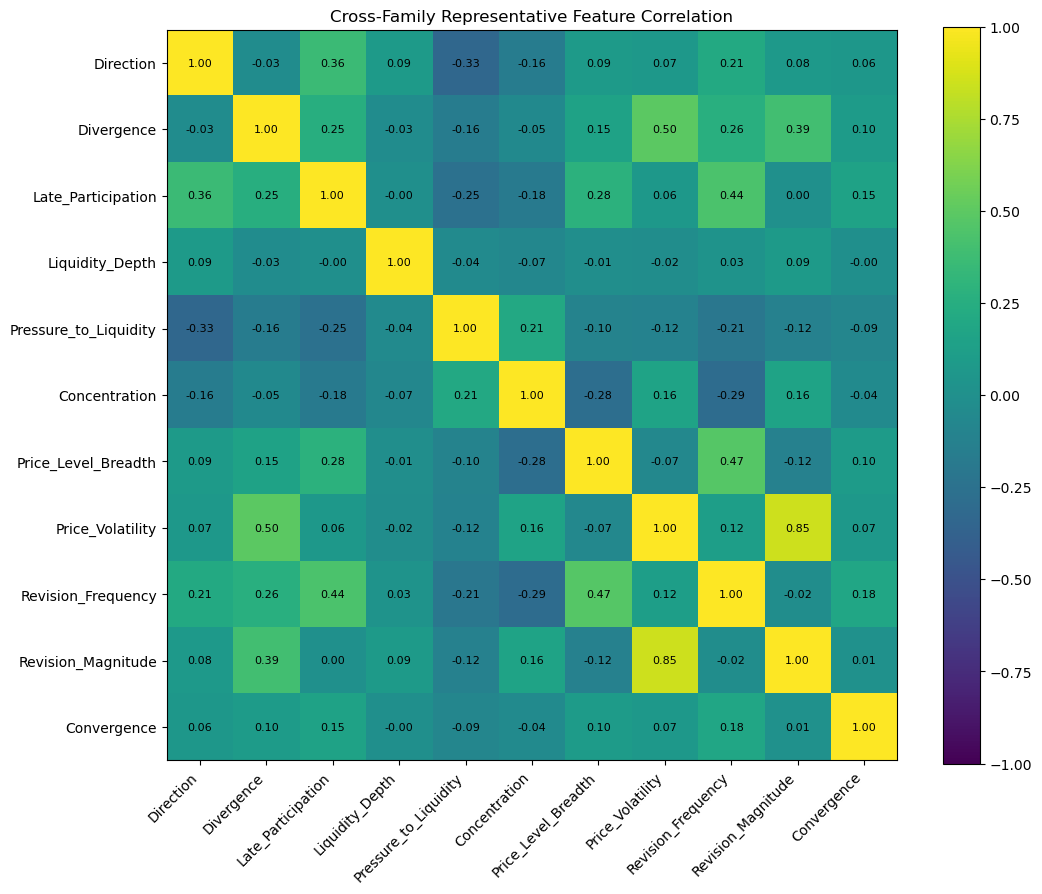

In [52]:
# Cross-family representative feature map
representative_features = {
    "Direction": "net_order_imbalance",
    "Divergence": "buy_price_divergence",
    "Late_Participation": "post920_volume_share",
    "Liquidity_Depth": "total_depth",
    "Pressure_to_Liquidity": "pressure_intensity_to_depth",
    "Concentration": "order_size_hhi",
    "Price_Level_Breadth": "n_price_levels",
    "Price_Volatility": "auction_price_volatility",
    "Revision_Frequency": "n_price_revisions",
    "Revision_Magnitude": "avg_price_revision_magnitude",
    "Convergence": "convergence_speed",
}

rep_cols = {
    label: col
    for label, col in representative_features.items()
    if col in feature_df.columns
}

rep_df = feature_df[list(rep_cols.values())].copy()
rep_df.columns = list(rep_cols.keys())

rep_corr = rep_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(rep_corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(rep_corr.columns)))
ax.set_yticks(range(len(rep_corr.index)))
ax.set_xticklabels(rep_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(rep_corr.index)
ax.set_title("Cross-Family Representative Feature Correlation")

for i in range(len(rep_corr.index)):
    for j in range(len(rep_corr.columns)):
        value = rep_corr.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Optional Exploratory Mechanism Checks

The following state analyses are kept as optional interpretation checks. They are useful for explaining why several feature families may matter, but they should **not** replace the next notebook's target-aware single-factor evaluation against `ret_0930_0935`.


In [53]:
# ============================================================
# Optional State 1: Divergence × Late-Stage Participation
# ============================================================

state_df = feature_df.copy()

divergence_feature = "buy_price_divergence"
late_participation_feature = "post920_volume_share"

state_df["divergence_state"] = np.where(
    state_df[divergence_feature] >= state_df[divergence_feature].median(),
    "High Divergence",
    "Low Divergence"
)

state_df["late_participation_state"] = np.where(
    state_df[late_participation_feature] >= state_df[late_participation_feature].median(),
    "High Late Participation",
    "Low Late Participation"
)

state_df["auction_state"] = (
    state_df["divergence_state"] + " × " + state_df["late_participation_state"]
)

state_order = [
    "Low Divergence × Low Late Participation",
    "Low Divergence × High Late Participation",
    "High Divergence × Low Late Participation",
    "High Divergence × High Late Participation",
]

state_df["auction_state"] = pd.Categorical(
    state_df["auction_state"],
    categories=state_order,
    ordered=True
)

state_summary = (
    state_df
    .groupby("auction_state", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
        avg_path_smoothness=("price_path_smoothness", "mean"),
    )
    .reindex(state_order)
)

display(state_summary.round(4))


,n_stock_days,avg_price_volatility,avg_price_reversal,avg_convergence_speed,avg_path_smoothness
auction_state,,,,,
Low Divergence × Low Late Participation,338,0.0026,3.2763,0.8323,0.4439
Low Divergence × High Late Participation,212,0.0035,4.8406,0.9130,0.4244
High Divergence × Low Late Participation,212,0.0083,4.1943,0.8626,0.3607
High Divergence × High Late Participation,338,0.0076,6.3650,0.9671,0.3707


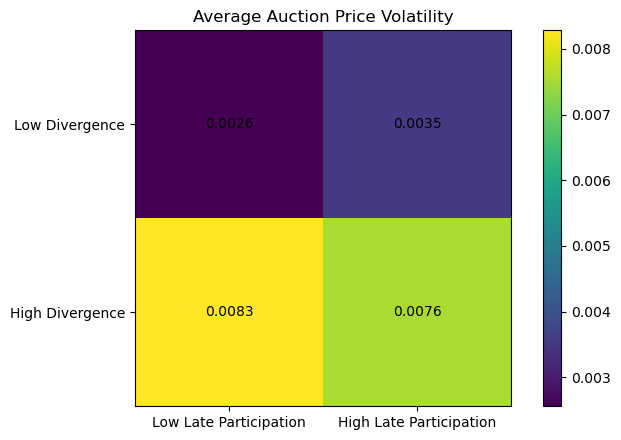

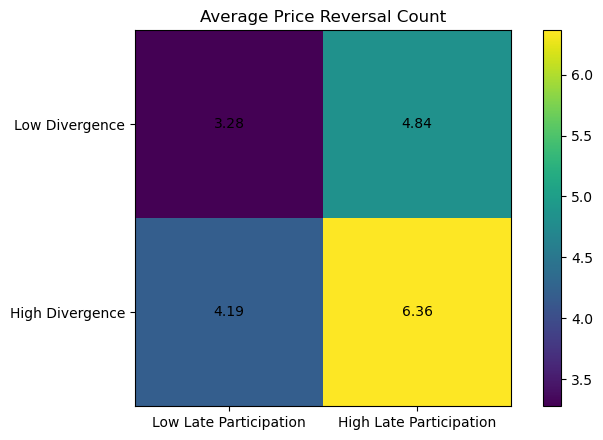

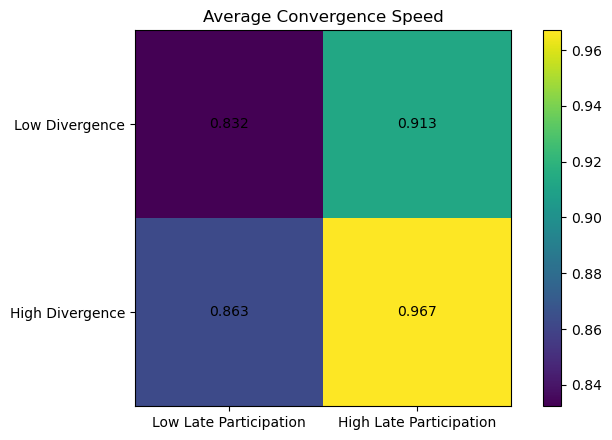

In [54]:
# Helper for 2×2 state heatmaps

def plot_2x2_state_heatmap(df, row_col, col_col, value_col, row_order, col_order, title, value_format=".3f"):
    matrix = (
        df
        .pivot_table(
            index=row_col,
            columns=col_col,
            values=value_col,
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=row_order, columns=col_order)
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix.values)

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, format(matrix.iloc[i, j], value_format), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "auction_price_volatility",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Auction Price Volatility",
    ".4f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "price_reversal_count",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Price Reversal Count",
    ".2f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "convergence_speed",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Convergence Speed",
    ".3f"
)


In [55]:
# ============================================================
# Optional State 2: Updating Magnitude × Late-Stage Participation
# ============================================================

updating_state_df = feature_df.copy()
updating_state_df["updating_magnitude"] = updating_state_df["imbalance_shift"].abs()

updating_state_df["updating_state"] = np.where(
    updating_state_df["updating_magnitude"] >= updating_state_df["updating_magnitude"].median(),
    "High Updating",
    "Low Updating"
)

updating_state_df["late_participation_state"] = np.where(
    updating_state_df["post920_volume_share"] >= updating_state_df["post920_volume_share"].median(),
    "High Late Participation",
    "Low Late Participation"
)

updating_state_df["auction_state_2"] = (
    updating_state_df["updating_state"] + " × " + updating_state_df["late_participation_state"]
)

state_order_2 = [
    "Low Updating × Low Late Participation",
    "Low Updating × High Late Participation",
    "High Updating × Low Late Participation",
    "High Updating × High Late Participation",
]

updating_state_df["auction_state_2"] = pd.Categorical(
    updating_state_df["auction_state_2"],
    categories=state_order_2,
    ordered=True,
)

state_summary_2 = (
    updating_state_df
    .groupby("auction_state_2", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_updating_magnitude=("updating_magnitude", "mean"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_2)
)

display(state_summary_2.round(4))


,n_stock_days,avg_updating_magnitude,avg_price_volatility,avg_price_reversal,avg_convergence_speed
auction_state_2,,,,,
Low Updating × Low Late Participation,308,0.1552,0.0047,3.5888,0.8239
Low Updating × High Late Participation,242,0.1769,0.0054,5.7250,0.9414
High Updating × Low Late Participation,242,0.6829,0.0049,3.6875,0.8697
High Updating × High Late Participation,308,0.7288,0.0065,5.8322,0.9503


,n_stock_days,avg_divergence,avg_n_price_levels,avg_n_price_revisions,avg_revision_magnitude,avg_price_reversal,avg_price_reversal_rate,avg_convergence_speed
auction_state_3,,,,,,,,
Low Divergence × Low Price-Level Breadth,318,0.0253,89.0472,5.3365,0.0062,3.0584,0.5298,0.8317
Low Divergence × High Price-Level Breadth,232,0.0286,198.3621,9.4784,0.0040,4.9612,0.5427,0.9052
High Divergence × Low Price-Level Breadth,230,0.0546,89.7826,7.3609,0.0120,4.0746,0.5390,0.9022
High Divergence × High Price-Level Breadth,320,0.0576,240.8688,13.5031,0.0086,6.5656,0.5049,0.9437


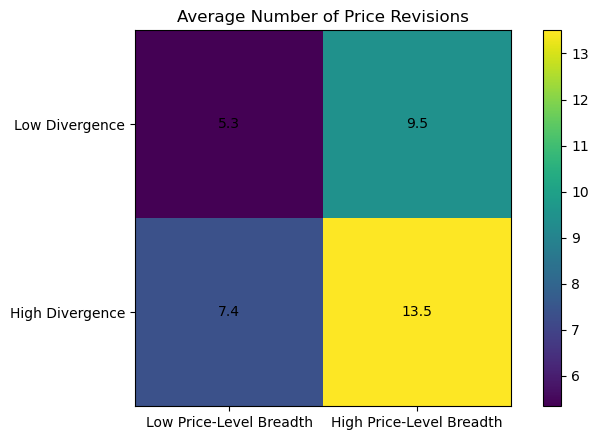

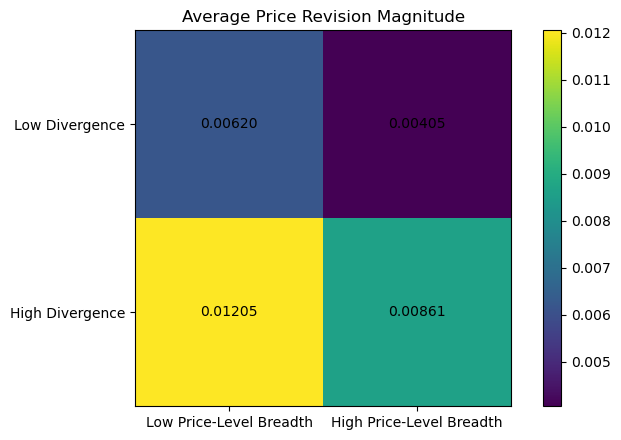

In [56]:
# ============================================================
# Optional State 3: Divergence × Price-Level Breadth
# ============================================================

breadth_state_df = feature_df.copy()

breadth_state_df["divergence_state"] = np.where(
    breadth_state_df["buy_price_divergence"] >= breadth_state_df["buy_price_divergence"].median(),
    "High Divergence",
    "Low Divergence"
)

breadth_state_df["breadth_state"] = np.where(
    breadth_state_df["n_price_levels"] >= breadth_state_df["n_price_levels"].median(),
    "High Price-Level Breadth",
    "Low Price-Level Breadth"
)

breadth_state_df["auction_state_3"] = (
    breadth_state_df["divergence_state"] + " × " + breadth_state_df["breadth_state"]
)

state_order_3 = [
    "Low Divergence × Low Price-Level Breadth",
    "Low Divergence × High Price-Level Breadth",
    "High Divergence × Low Price-Level Breadth",
    "High Divergence × High Price-Level Breadth",
]

breadth_state_df["auction_state_3"] = pd.Categorical(
    breadth_state_df["auction_state_3"],
    categories=state_order_3,
    ordered=True,
)

state_summary_3 = (
    breadth_state_df
    .groupby("auction_state_3", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_divergence=("buy_price_divergence", "mean"),
        avg_n_price_levels=("n_price_levels", "mean"),
        avg_n_price_revisions=("n_price_revisions", "mean"),
        avg_revision_magnitude=("avg_price_revision_magnitude", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_price_reversal_rate=("price_reversal_rate", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_3)
)

display(state_summary_3.round(4))

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "n_price_revisions",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Number of Price Revisions",
    ".1f"
)

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "avg_price_revision_magnitude",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Price Revision Magnitude",
    ".5f"
)


## Single-Stock Multi-Day Auction Process

To complement the cross-sectional feature analysis, this section visualizes the intraday auction process for a single stock across multiple trading days.

The objective is to examine whether auction price formation, order-book imbalance, and visible depth exhibit persistent or heterogeneous temporal patterns across stock-days.

Three dimensions are considered:

- **Mid Price Path**: evolution of the best bid-ask midpoint during the auction.
- **Depth Imbalance**: directional asymmetry between visible bid and ask depth.
- **Total Depth**: evolution of visible order-book liquidity.

This visualization provides a path-level interpretation of the stock-day features constructed above.

Selected stock: 600396.SH
Selected dates: [Timestamp('2026-03-11 00:00:00'), Timestamp('2026-03-12 00:00:00'), Timestamp('2026-03-13 00:00:00'), Timestamp('2026-03-16 00:00:00'), Timestamp('2026-03-17 00:00:00')]


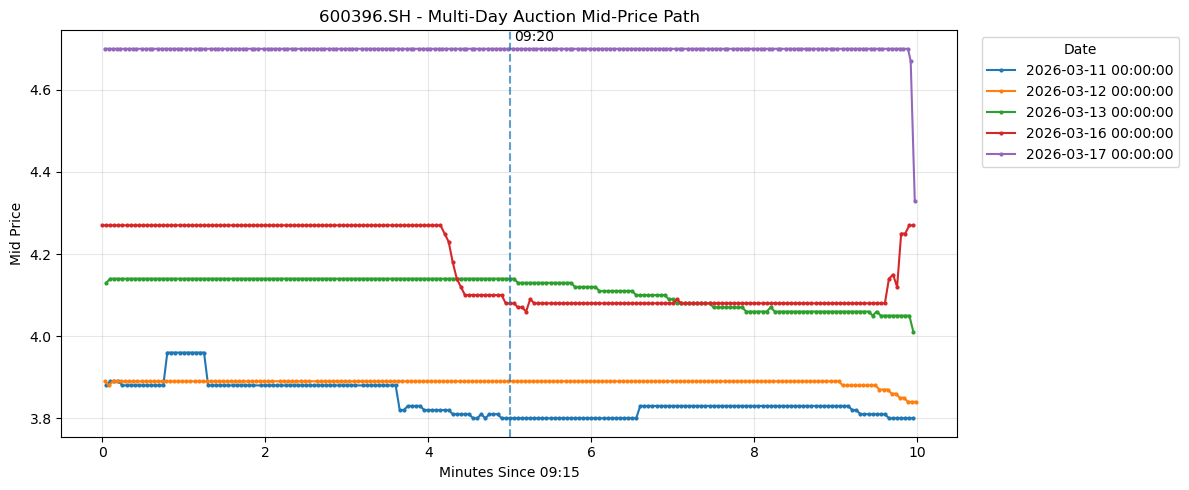

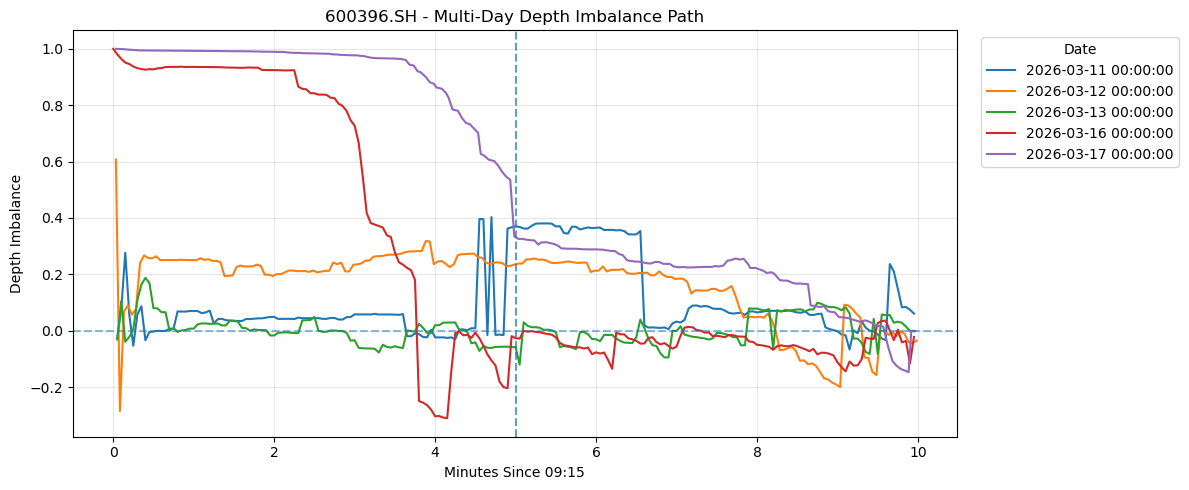

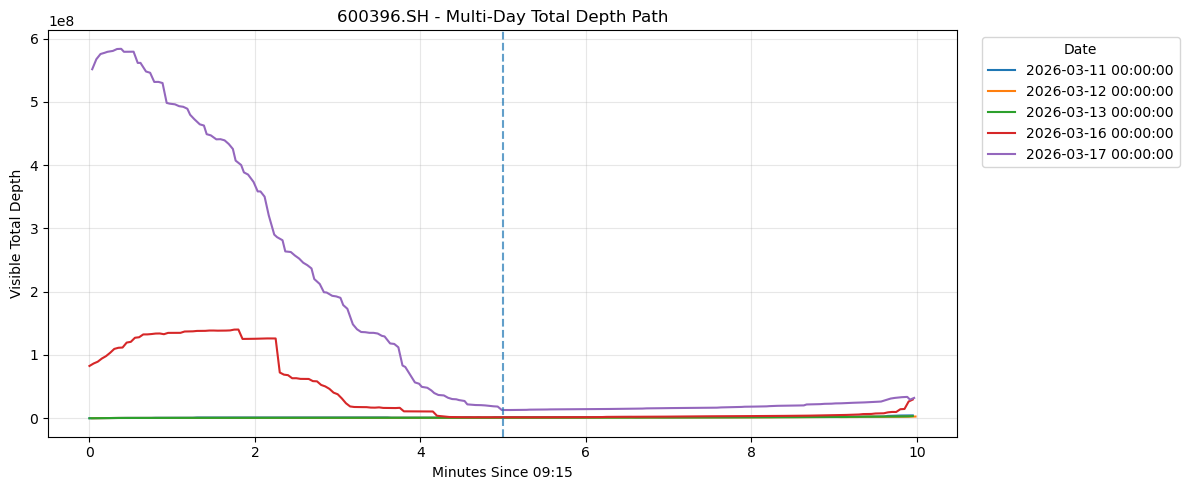

In [57]:
# ============================================================
# Single-Stock Multi-Day Auction Process
# ============================================================

plot_df = qtick_auction.copy()

# ------------------------------------------------------------
# 1. Reconstruct datetime if needed
# ------------------------------------------------------------

if "datetime" not in plot_df.columns:
    plot_df["datetime"] = pd.to_datetime(
        plot_df["date"].astype(str)
        + " "
        + plot_df["time"].astype(str)
    )

# ------------------------------------------------------------
# 2. Construct path variables
# ------------------------------------------------------------

bp0 = (
    pd.to_numeric(plot_df["bp0"], errors="coerce")
    .replace(0, np.nan)
)

ap0 = (
    pd.to_numeric(plot_df["ap0"], errors="coerce")
    .replace(0, np.nan)
)

plot_df["mid_price"] = (
    bp0 + ap0
) / 2


# Visible depth: bp0-bp9 / ap0-ap9
bid_volume_cols = [
    f"bv{i}"
    for i in range(10)
    if f"bv{i}" in plot_df.columns
]

ask_volume_cols = [
    f"av{i}"
    for i in range(10)
    if f"av{i}" in plot_df.columns
]


plot_df["bid_depth"] = (
    plot_df[bid_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["ask_depth"] = (
    plot_df[ask_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["total_depth"] = (
    plot_df["bid_depth"]
    + plot_df["ask_depth"]
)

plot_df["depth_imbalance"] = np.where(
    plot_df["total_depth"] > 0,
    (
        plot_df["bid_depth"]
        - plot_df["ask_depth"]
    )
    / plot_df["total_depth"],
    np.nan
)


# ------------------------------------------------------------
# 3. Select one stock and multiple dates
# ------------------------------------------------------------

selected_code = (
    plot_df["code"]
    .value_counts()
    .index[0]
)

available_dates = (
    plot_df.loc[
        plot_df["code"] == selected_code,
        "date"
    ]
    .drop_duplicates()
    .sort_values()
)

selected_dates = available_dates[:5]


single_stock_df = (
    plot_df[
        (plot_df["code"] == selected_code)
        & (plot_df["date"].isin(selected_dates))
    ]
    .copy()
)


print("Selected stock:", selected_code)

print(
    "Selected dates:",
    list(selected_dates)
)


# ------------------------------------------------------------
# 4. Create relative auction time
# ------------------------------------------------------------

single_stock_df["auction_minute"] = (
    single_stock_df["datetime"]
    - single_stock_df["datetime"].dt.normalize()
    - pd.Timedelta(hours=9, minutes=15)
).dt.total_seconds() / 60


# ============================================================
# Plot 1: Mid Price Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["mid_price"],
        marker="o",
        markersize=2,
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.text(
    5.05,
    plt.ylim()[1],
    "09:20",
    va="top"
)

plt.title(
    f"{selected_code} - Multi-Day Auction Mid-Price Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Mid Price"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 2: Depth Imbalance Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["depth_imbalance"],
        label=str(date)
    )

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Depth Imbalance Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Depth Imbalance"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 3: Total Depth Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["total_depth"],
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Total Depth Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Visible Total Depth"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Week 4 Feature Coverage Check

The final feature table now covers the required Week 4 feature directions:

- **Price Features**: auction price range, volatility, last-minute price change, price revision features
- **Order Features**: submitted volume, buy/sell volume, imbalance, order size, price-level distribution
- **Cancellation Features**: cancellation volume, cancellation ratio, order-level cancellation rate
- **Execution Features**: auction trade volume, trade amount, VWAP, trade count
- **Order Book Features**: bid/ask depth, depth imbalance, pressure-to-liquidity
- **Historical Features**: previous-day return, previous-day amount, rolling volatility, limit-distance controls

Market-level and sector-level features are not included at this stage due to data availability and are reserved for later model enhancement.

## Week 4 Output and Next Step

This notebook should stop at a prediction-ready auction feature table.

**Keep for next stage:**
- `feature_df`: stock-day auction feature table
- `feature_registry`: feature family / priority metadata
- `core_candidate_features`: first-pass candidate feature list
- `secondary_candidate_features`: cancellation and other lower-priority candidates

**Next notebook:** `05_5min_return_single_factor.ipynb`

Main task:
1. Construct `ret_0930_0935 = price_09:35 / price_09:30 - 1`.
2. Merge the 5-minute return label with `feature_df`.
3. Evaluate each feature as a single factor using IC, Rank IC, direction accuracy, and grouped returns.
4. Use target-aware results to decide which features survive.


In [58]:
# ============================================================
# Export feature table and feature registry for the next notebook
# ============================================================

feature_df.to_csv("04_auction_feature_table.csv", index=False)
feature_registry.to_csv("04_feature_registry.csv", index=False)

print("Saved:")
print("- 04_auction_feature_table.csv")
print("- 04_feature_registry.csv")
print("feature_df shape:", feature_df.shape)


Saved:
- 04_auction_feature_table.csv
- 04_feature_registry.csv
feature_df shape: (1100, 63)


In [59]:
# ============================================================
# Export Prediction-Ready Auction Features
# ============================================================

from pathlib import Path

AUCTION_FEATURE_PATH = Path(
    "../data/auction_features_prediction_ready.csv"
)

AUCTION_FEATURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

auction_feature_export = feature_df.copy()

auction_feature_export["date"] = pd.to_datetime(
    auction_feature_export["date"]
).dt.strftime("%Y-%m-%d")

# Ensure one row per stock-date
duplicate_keys = (
    auction_feature_export
    .duplicated(
        subset=["code", "date"]
    )
    .sum()
)

if duplicate_keys > 0:
    raise ValueError(
        f"auction feature_df contains "
        f"{duplicate_keys} duplicate code-date rows."
    )

auction_feature_export.to_csv(
    AUCTION_FEATURE_PATH,
    index=False
)

print(
    "Auction features exported to:",
    AUCTION_FEATURE_PATH.resolve()
)

print(
    "Export shape:",
    auction_feature_export.shape
)

print(
    "Stocks:",
    auction_feature_export["code"].nunique()
)

print(
    "Dates:",
    auction_feature_export["date"].nunique()
)

print(
    "Feature columns:",
    auction_feature_export.shape[1] - 2
)

display(
    auction_feature_export.head()
)

Auction features exported to: C:\Users\work\OneDrive\Documents\level2-research\data\auction_features_prediction_ready.csv
Export shape: (1100, 63)
Stocks: 50
Dates: 22
Feature columns: 61


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance,last_minute_submit_imbalance,last_minute_net_order_imbalance,cancel_volume_ratio,cancel_rate_by_order,last_minute_submit_volume_share,last_minute_submit_count_share,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share,largest_order_share,order_size_hhi,n_price_levels,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_avg_trade_price,auction_vwap,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,distance_to_upper_limit,distance_to_lower_limit,convergence_speed,price_path_smoothness,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude,price_reversal_rate
0,000026.SZ,2026-03-11,441,434,7,640600,33800,1476.036866,600.0,36200,170800,469800,26200,7600,-0.466750,-0.523401,-0.653167,-0.653167,0.052763,0.016129,0.150328,0.122120,0.040276,0.033856,0.006420,-0.302784,-0.750320,-0.447536,0,0.366375,0.056510,0.012092,164,44466.666667,-0.220519,51171.428571,-0.144989,61900,-0.256866,-6.724138,6.724138,0.014585,0.006008,-0.001269,7.0,45.0,57000.0,3.642400e+09,132577.777778,63901.754386,NaN,NaN,NaN,NaN,0.099743,0.099743,1.0,0.021277,10,0.009011,0.011097,0.014801,0.700000
1,000026.SZ,2026-03-12,338,332,6,642400,17500,1934.939759,900.0,36200,146200,496200,7100,10400,-0.544832,-0.554809,-0.951417,-0.951417,0.027242,0.018072,0.115349,0.099398,0.037675,0.038410,-0.000735,-0.443277,-0.683745,-0.240468,0,0.422323,0.056351,0.015540,139,26342.307692,-0.064359,49275.000000,-0.103268,48600,-0.049383,-13.286611,13.286611,0.007124,0.001665,-0.003868,4.0,26.0,40700.0,3.584400e+09,118846.153846,88068.796069,-1.0,0.0,NaN,NaN,0.099741,0.099741,1.0,0.030303,10,0.002129,0.001931,0.004534,0.400000
2,000026.SZ,2026-03-13,316,305,11,468200,36100,1535.081967,700.0,16300,123600,344600,7900,28200,-0.472021,-0.464476,-0.332406,-0.332406,0.077104,0.036066,0.153567,0.104918,0.035849,0.035860,-0.000011,-0.476216,-0.456212,0.020004,0,0.209739,0.034814,0.011667,138,10107.142857,-0.081014,26975.000000,0.049799,29500,-0.003390,-21.865724,21.865724,0.013636,0.006157,-0.010283,4.0,29.0,50900.0,2.274760e+09,95400.000000,44690.766208,-1.0,0.0,NaN,NaN,0.100000,0.100000,0.0,0.000000,7,0.006828,0.005810,0.012187,0.571429
3,000026.SZ,2026-03-16,262,259,3,394100,7000,1521.621622,700.0,19200,96500,297600,7000,0,-0.510277,-0.537587,-0.738241,-0.738241,0.017762,0.011583,0.124080,0.146718,0.041171,0.045469,-0.004299,-0.461838,-0.600874,-0.139036,0,0.348389,0.048719,0.013250,117,26159.090909,-0.424300,38660.000000,-0.324045,30900,0.042071,-7.687576,7.687576,0.009278,0.001381,-0.003333,3.0,36.0,22300.0,2.287350e+09,137041.666667,102571.748879,-1.0,0.0,NaN,NaN,0.100000,0.100000,1.0,0.875000,5,0.002127,0.000667,0.005302,0.600000
4,000026.SZ,2026-03-17,326,312,14,530800,64300,1701.282051,800.0,20000,189200,341600,24200,40100,-0.287114,-0.292605,-0.110811,-0.110811,0.121138,0.044872,0.139412,0.092949,0.049641,0.049777,-0.000136,-0.243976,-0.359155,-0.115179,0,0.374529,0.037679,0.012190,136,27687.500000,-0.136361,58640.000000,-0.085951,78200,-0.150895,-5.504289,5.504289,0.038488,0.007395,-0.006127,12.0,48.0,119300.0,8.046500e+09,103629.166667,67447.611065,-1.0,0.0,0.0,0.0,0.100275,0.100275,1.0,0.028902,19,0.006267,0.004084,0.023368,0.631579
